# Notebook for basic Data Analysis MQLP Project

### Save Workspace

In [ ]:
import pickle

def save_workspace(filename="workspace.pkl"):
    workspace = {}
    for k, v in globals().items():
        try:
            pickle.dumps(v)
            workspace[k] = v
        except Exception:
            pass  # skip non-picklable objects

    with open(filename, "wb") as f:
        pickle.dump(workspace, f)

    print(f"✅ Saved {len(workspace)} variables to {filename}")

save_workspace()

In [2]:
import pandas as pd

# -----------------------------
# File paths
# -----------------------------
main_path = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data\result_df\all_foraging_data_07_02_24.csv"
side_path = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data\all_PCL_details_ae_03_27_25.csv"

# -----------------------------
# Load data
# -----------------------------
main_df = pd.read_csv(main_path)
side_df = pd.read_csv(side_path)

# -----------------------------
# Keep only needed columns from side file
# -----------------------------
factor_cols = ["fileID", "Factor_1", "Factor_2", "Factor_3"]

missing_cols = [c for c in factor_cols if c not in side_df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in side file: {missing_cols}")

side_subset = side_df[factor_cols].copy()

# -----------------------------
# Remove duplicates in side data (if any)
# -----------------------------
side_subset = side_subset.drop_duplicates(subset="fileID")

# -----------------------------
# Merge (LEFT JOIN: keep all main data)
# -----------------------------
merged_df = main_df.merge(side_subset, on="fileID", how="left")

# -----------------------------
# Check merge quality
# -----------------------------
num_missing = merged_df["Factor_1"].isna().sum()
print(f"Rows with missing Factor values after merge: {num_missing}")

# -----------------------------
# Save output
# -----------------------------
output_path = main_path.replace(".csv", "_with_PCL_factors.csv")
merged_df.to_csv(output_path, index=False)

print(f"✅ Merged file saved to: {output_path}")

Rows with missing Factor values after merge: 150
✅ Merged file saved to: C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data\result_df\all_foraging_data_07_02_24_with_PCL_factors.csv


# PCL factor analysis plot

### Load Workspace

In [6]:
import pickle
import types

class DummyObject:
    def __init__(self, *args, **kwargs):
        pass

class SafeUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == "__main__":
            # return a dummy function for any missing notebook-defined object
            return DummyObject
        return super().find_class(module, name)

with open("workspace.pkl", "rb") as f:
    workspace = SafeUnpickler(f).load()

globals().update(workspace)

print(f"✅ Loaded {len(workspace)} variables")

✅ Loaded 168 variables


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import subprocess

✅ Data loaded. Using 20 columns and 297 rows after dropping NaN.



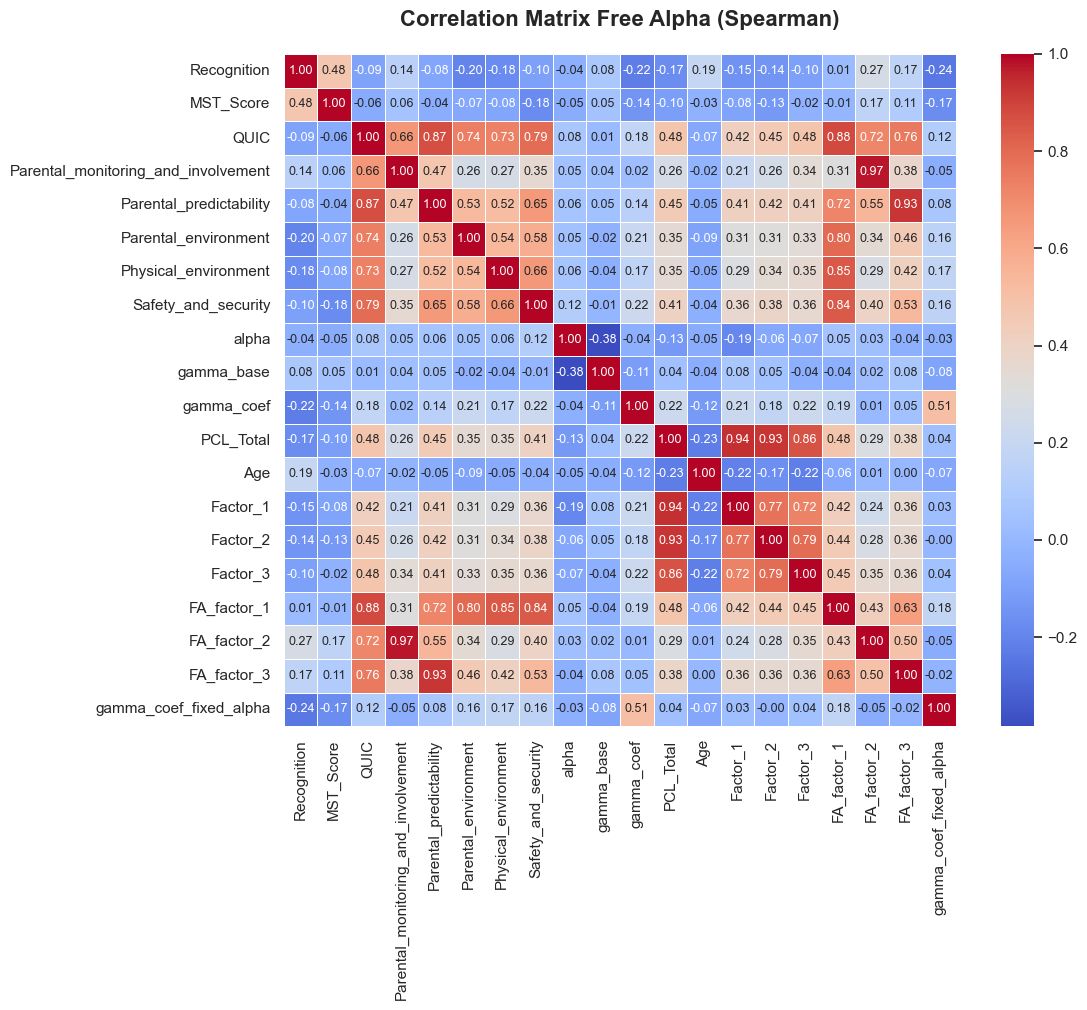

🖼️ Heatmap saved successfully to:
C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new\correlation_heatmap.png


In [1]:
# === Install required packages if not already installed ===
import sys
import subprocess

def install_if_missing(package):
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

for pkg in ["pandas", "numpy", "matplotlib", "seaborn"]:
    install_if_missing(pkg)

# === Import packages ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# === Load dataset ===
file_path = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data\result_df\all_foraging_data_07_02_24_with_PCL_factors.csv"
#file_path = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data\result_df\all_result_df.csv"
df = pd.read_csv(file_path)

#=== Select relevant columns ===
# cols = [
#     "Recognition", "MST_Score", "QUIC",
#     "Parental_monitoring_and_involvement", "Parental_predictability",
#     "Parental_environment", "Physical_environment", "Safety_and_security",
#     "gamma_base_fits", "gamma_coef_fits", "beta", "epsilon", "Age"
# ]

cols = [
    "Recognition", "MST_Score", "QUIC",
    "Parental_monitoring_and_involvement", "Parental_predictability",
    "Parental_environment", "Physical_environment", "Safety_and_security",
    "alpha",	"gamma_base",	"gamma_coef", "PCL_Total"
, "Age", "Factor_1","Factor_2","Factor_3", "FA_factor_1","FA_factor_2","FA_factor_3","gamma_coef_fixed_alpha",]
# Keep only columns that actually exist
cols = [c for c in cols if c in df.columns]
data = df[cols]   # keep all rows, even with NaN


print(f"✅ Data loaded. Using {len(cols)} columns and {data.shape[0]} rows after dropping NaN.\n")

# === Compute correlation matrix ===
corr = data.corr(method="pearson")

# --- Plot the heatmap ---
plt.figure(figsize=(12, 10))
sns.set_theme(style="whitegrid")
sns.set(font_scale=1.0)

ax = sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm",
    square=True, cbar=True, linewidths=0.5,
    annot_kws={"size": 9}
)

plt.title("Correlation Matrix Free Alpha (Spearman)", fontsize=16, fontweight="bold", pad=20)
plt.tight_layout()

# --- Save the figure properly ---
img_path = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new\correlation_heatmap.png"
plt.savefig(img_path, dpi=300, bbox_inches="tight", facecolor="white")

# --- Display to verify ---
plt.show()

print(f"🖼️ Heatmap saved successfully to:\n{img_path}")



## Multiple correction comparison to justify using ELU factor 1

In [2]:
import os
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from statsmodels.stats.multitest import multipletests

# ============================================================
# Multiple-comparison correction:
# QUIC/ELU factors 1-6 vs gamma_coef
# Pearson + Spearman
# ============================================================

save_dir = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new"
os.makedirs(save_dir, exist_ok=True)

# Choose outcome parameter
y_var = "gamma_coef"

# Six ELU factors
factor_vars = [f"FA_factor_{i}" for i in range(1, 7)]
factor_vars = [f for f in factor_vars if f in df.columns]

if y_var not in df.columns:
    raise ValueError(f"Missing outcome variable: {y_var}")

if len(factor_vars) == 0:
    raise ValueError("No FA_factor_* columns found.")

print("Testing factors:", factor_vars)
print("Outcome:", y_var)

# ============================================================
# Raw correlations
# ============================================================

rows = []

for x_var in factor_vars:
    clean = df[[x_var, y_var]].copy()
    clean[x_var] = pd.to_numeric(clean[x_var], errors="coerce")
    clean[y_var] = pd.to_numeric(clean[y_var], errors="coerce")
    clean = clean.replace([np.inf, -np.inf], np.nan).dropna()

    if len(clean) < 3:
        rows.append({
            "factor": x_var,
            "n": len(clean),
            "pearson_r": np.nan,
            "pearson_p_raw": np.nan,
            "spearman_rho": np.nan,
            "spearman_p_raw": np.nan,
        })
        continue

    pear_r, pear_p = pearsonr(clean[x_var], clean[y_var])
    spear_rho, spear_p = spearmanr(clean[x_var], clean[y_var])

    rows.append({
        "factor": x_var,
        "n": len(clean),
        "pearson_r": pear_r,
        "pearson_p_raw": pear_p,
        "spearman_rho": spear_rho,
        "spearman_p_raw": spear_p,
    })

corr_df = pd.DataFrame(rows)

# ============================================================
# FDR correction across the six factor tests
# Done separately for Pearson and Spearman
# ============================================================

valid_pearson = corr_df["pearson_p_raw"].notna()
valid_spearman = corr_df["spearman_p_raw"].notna()

corr_df.loc[valid_pearson, "pearson_p_fdr"] = multipletests(
    corr_df.loc[valid_pearson, "pearson_p_raw"],
    method="fdr_bh"
)[1]

corr_df.loc[valid_spearman, "spearman_p_fdr"] = multipletests(
    corr_df.loc[valid_spearman, "spearman_p_raw"],
    method="fdr_bh"
)[1]

# Optional stricter Bonferroni correction
corr_df.loc[valid_pearson, "pearson_p_bonf"] = multipletests(
    corr_df.loc[valid_pearson, "pearson_p_raw"],
    method="bonferroni"
)[1]

corr_df.loc[valid_spearman, "spearman_p_bonf"] = multipletests(
    corr_df.loc[valid_spearman, "spearman_p_raw"],
    method="bonferroni"
)[1]

# Significance flags
corr_df["pearson_sig_fdr_05"] = corr_df["pearson_p_fdr"] < 0.05
corr_df["spearman_sig_fdr_05"] = corr_df["spearman_p_fdr"] < 0.05
corr_df["pearson_sig_bonf_05"] = corr_df["pearson_p_bonf"] < 0.05
corr_df["spearman_sig_bonf_05"] = corr_df["spearman_p_bonf"] < 0.05

# Sort by Pearson raw p
corr_df = corr_df.sort_values("pearson_p_raw")

# ============================================================
# Print results
# ============================================================

print("\n===================================================")
print("ELU factors vs gamma_coef: raw + corrected p-values")
print("Correction family = six FA_factor correlations")
print("===================================================\n")

display_cols = [
    "factor", "n",
    "pearson_r", "pearson_p_raw", "pearson_p_fdr", "pearson_p_bonf", "pearson_sig_fdr_05", "pearson_sig_bonf_05",
    "spearman_rho", "spearman_p_raw", "spearman_p_fdr", "spearman_p_bonf", "spearman_sig_fdr_05", "spearman_sig_bonf_05"
]

print(corr_df[display_cols].round(5))

# Specifically print FA_factor_1
if "FA_factor_1" in corr_df["factor"].values:
    f1 = corr_df[corr_df["factor"] == "FA_factor_1"].iloc[0]
    print("\nFA_factor_1 result:")
    print(f"Pearson:  r = {f1['pearson_r']:.4f}, raw p = {f1['pearson_p_raw']:.4g}, "
          f"FDR p = {f1['pearson_p_fdr']:.4g}, Bonferroni p = {f1['pearson_p_bonf']:.4g}")
    print(f"Spearman: rho = {f1['spearman_rho']:.4f}, raw p = {f1['spearman_p_raw']:.4g}, "
          f"FDR p = {f1['spearman_p_fdr']:.4g}, Bonferroni p = {f1['spearman_p_bonf']:.4g}")

# ============================================================
# Save
# ============================================================

out_path = os.path.join(save_dir, "ELU_factors_vs_gamma_coef_multiple_comparison_corrected.csv")
corr_df.to_csv(out_path, index=False)

print(f"\nSaved corrected correlation table to:\n{out_path}")

Testing factors: ['FA_factor_1', 'FA_factor_2', 'FA_factor_3', 'FA_factor_4', 'FA_factor_5', 'FA_factor_6']
Outcome: gamma_coef

ELU factors vs gamma_coef: raw + corrected p-values
Correction family = six FA_factor correlations

        factor    n  pearson_r  pearson_p_raw  pearson_p_fdr  pearson_p_bonf  \
0  FA_factor_1  297    0.19439        0.00076        0.00454         0.00454   
3  FA_factor_4  297    0.12208        0.03547        0.10642         0.21283   
5  FA_factor_6  297    0.08979        0.12257        0.24514         0.73542   
4  FA_factor_5  297   -0.04893        0.40084        0.51678         1.00000   
2  FA_factor_3  297    0.04590        0.43065        0.51678         1.00000   
1  FA_factor_2  297    0.00862        0.88244        0.88244         1.00000   

   pearson_sig_fdr_05  pearson_sig_bonf_05  spearman_rho  spearman_p_raw  \
0                True                 True       0.17577         0.00237   
3               False                False       0.14546  

## Correlation plot

Behavior metrics: ['FA_factor_1']
Model parameters: ['gamma_coef']


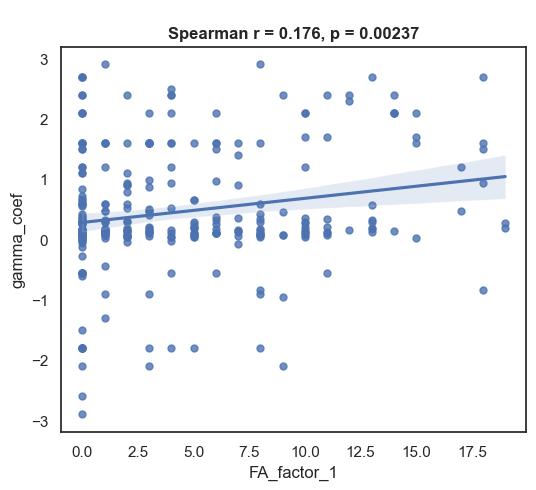

Saved: C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new\scatter_plots\FA_factor_1_vs_gamma_coef.png

🎉 All scatter plots generated!


In [14]:
# ===============================================================
# Generate scatter plots for model parameters vs behavioral metrics
# ===============================================================

import os
from scipy.stats import pearsonr
from scipy.stats import spearmanr

# === Output folder ===
out_dir = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new\scatter_plots"
os.makedirs(out_dir, exist_ok=True)

# === Define variables ===
# behavior_vars = [
#     "Recognition", "MST_Score", "QUIC",
#     "Parental_monitoring_and_involvement", "Parental_predictability",
#     "Parental_environment", "Physical_environment", "Safety_and_security"
# ]

behavior_vars = [
"FA_factor_1"
]

model_vars = ["gamma_coef"]



# Keep only valid columns
behavior_vars = [b for b in behavior_vars if b in data.columns]
model_vars = [m for m in model_vars if m in data.columns]

print("Behavior metrics:", behavior_vars)
print("Model parameters:", model_vars)

sns.set_theme(style="white")

# === Loop and generate plots ===
for b in behavior_vars:
    for m in model_vars:

        # Extract columns
        x = data[m]
        y = data[b]

        # Drop missing
        sub = pd.DataFrame({m: x, b: y}).dropna()

        # Compute Pearson stats
        r, p = spearmanr(sub[m], sub[b])

        # Plot
        plt.figure(figsize=(6, 5))
        sns.regplot(x=b, y=m, data=sub, ci=95, scatter_kws={'s': 25})

        plt.title(f"\nSpearman r = {r:.3f}, p = {p:.3g}",
                  fontsize=12, fontweight="bold")
        plt.xlabel(b)
        plt.ylabel(m)

        #plt.tight_layout()

        # Save file
        fname = f"{b}_vs_{m}.png".replace(" ", "_")
        fpath = os.path.join(out_dir, fname)
        
        plt.savefig(fpath, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

        print(f"Saved: {fpath}")

print("\n🎉 All scatter plots generated!")


### S2

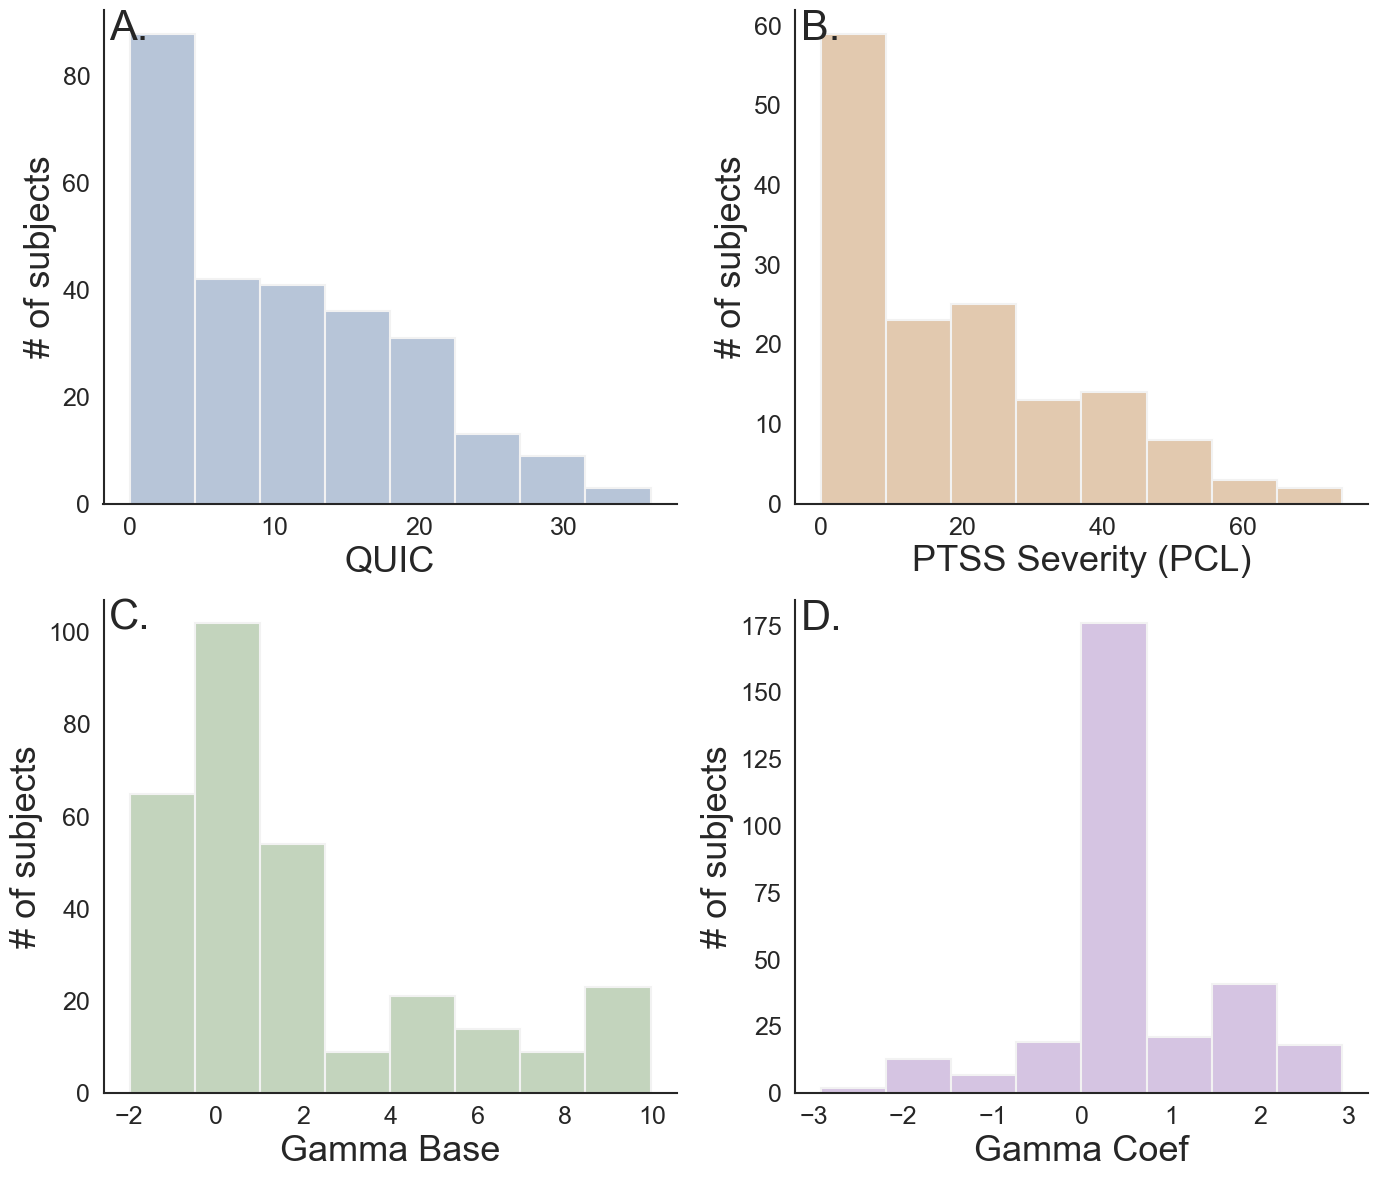

Saved figure to:
C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new\histogram_2x2_QUIC_PCL_gamma.png


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ============================================================
# 1. Clean data
# ============================================================
plot_cols = ["QUIC", "PCL_Total", "gamma_base", "gamma_coef"]
missing_cols = [c for c in plot_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in df: {missing_cols}")

plot_df = df[plot_cols].copy()

# ============================================================
# 2. Style settings
# ============================================================
sns.set_theme(style="white")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 26,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "axes.linewidth": 1.5
})

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

panel_letters = ["A.", "B.", "C.", "D."]
titles = ["QUIC", "PTSS Severity (PCL)", "Gamma Base", "Gamma Coef"]
xvars = ["QUIC", "PCL_Total", "gamma_base", "gamma_coef"]

# soft colors similar to your examples
colors = ["#9FB2CC", "#D9B894", "#AFC6A7", "#C8B0D9"]

# ============================================================
# 3. Plot each histogram
# ============================================================
for i, (ax, var, title, color, letter) in enumerate(zip(axes, xvars, titles, colors, panel_letters)):
    vals = plot_df[var].dropna()

    sns.histplot(
        vals,
        bins=8,
        ax=ax,
        color=color,
        edgecolor="#F2F2F2",
        linewidth=1.5
    )

    # axis labels
    ax.set_xlabel(title)
    ax.set_ylabel("# of subjects")

    # remove top/right spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # panel label in upper-left corner
    ax.text(
        0.01, 1, letter,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=30,
        fontweight="normal"
    )

# ============================================================
# 4. Optional x-axis label tweaks
# ============================================================
# If you want more compact labels for bottom row instead, use:
# axes[2].set_xlabel("Gamma Base")
# axes[3].set_xlabel("Gamma Coef")

plt.tight_layout()

# ============================================================
# 5. Save
# ============================================================
out_path = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new\histogram_2x2_QUIC_PCL_gamma.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved figure to:\n{out_path}")

### S5 demographic

C:\Users\zyfxl\AppData\Local\Temp\ipykernel_45216\2431869878.py:144: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\zyfxl\AppData\Local\Temp\ipykernel_45216\2431869878.py:144: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\zyfxl\AppData\Local\Temp\ipykernel_45216\2431869878.py:144: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\zyfxl\AppData\Local\Temp\ipykernel_45216\2431869878.py:144: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable t

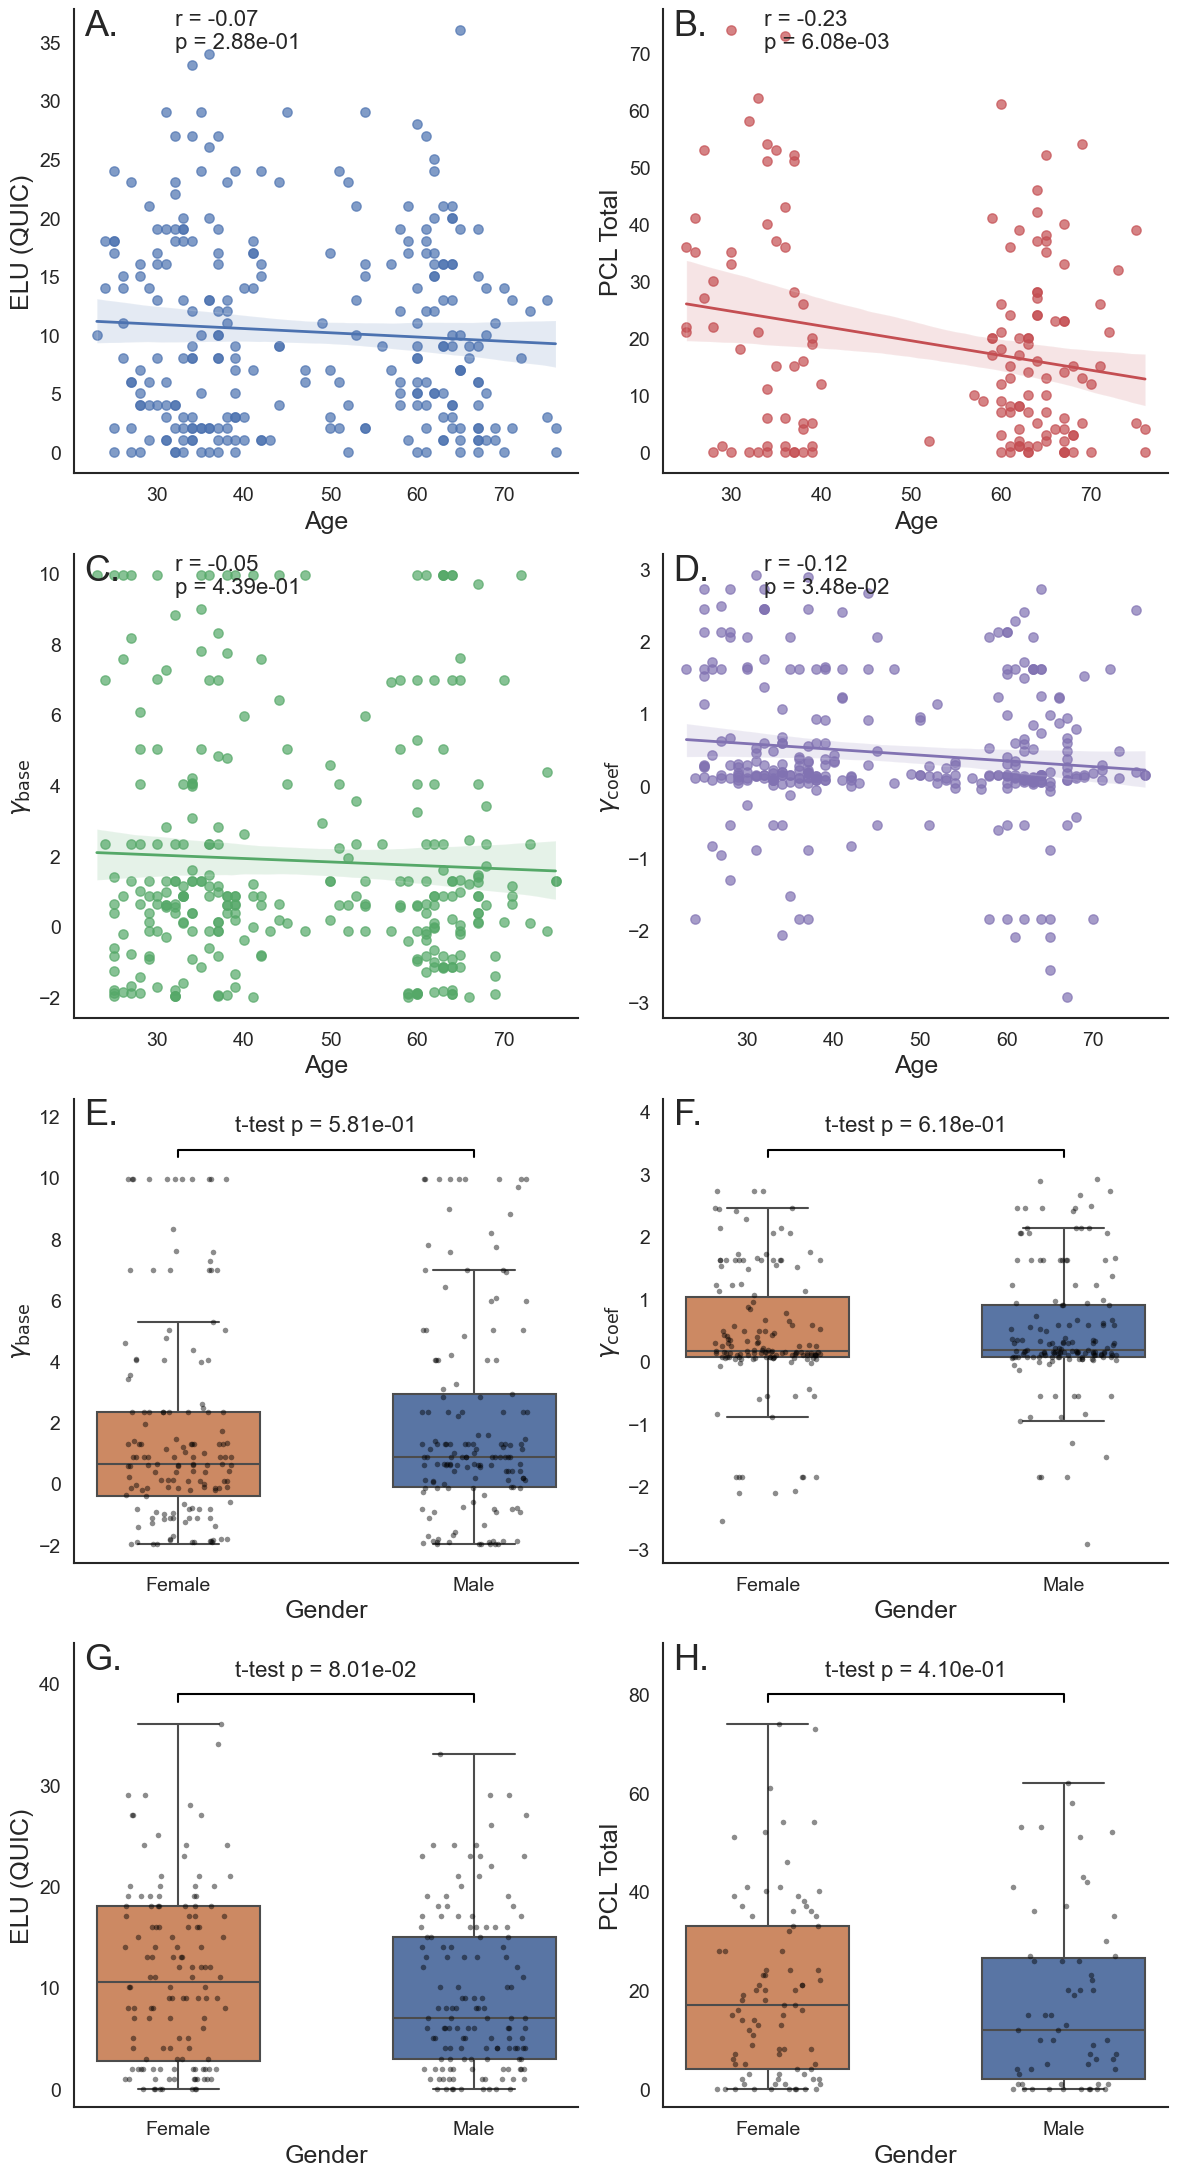

Saved figure to:
C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new\age_gender_massive_comparison.png


In [9]:
# ============================================================
# MASSIVE COMPARISON FIGURE:
# Age x QUIC, PCL, gamma_base, gamma_coef
# Gender x gamma_base, gamma_coef, QUIC, PCL
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, ttest_ind

# ============================================================
# 1. Basic style
# ============================================================
sns.set_theme(style="white")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 18,
    "axes.titlesize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.linewidth": 1.5
})

# ============================================================
# 2. Find gender column automatically
# ============================================================
possible_gender_cols = ["Gender", "gender", "sex", "Sex"]
gender_col = None
for c in possible_gender_cols:
    if c in df.columns:
        gender_col = c
        break

if gender_col is None:
    raise ValueError(
        "Could not find a gender column. "
        "Please rename your gender column to one of: "
        f"{possible_gender_cols}"
    )

# ============================================================
# 3. Keep only needed columns
# ============================================================
needed_cols = ["Age", "QUIC", "PCL_Total", "gamma_base", "gamma_coef", gender_col]
missing = [c for c in needed_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

plot_df = df[needed_cols].copy()

# ============================================================
# 4. Clean / standardize gender labels
# ============================================================
def clean_gender(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in ["m", "male", "man"]:
        return "Male"
    elif s in ["f", "female", "woman"]:
        return "Female"
    else:
        return np.nan

plot_df["Gender_clean"] = plot_df[gender_col].apply(clean_gender)

# ============================================================
# 5. Pretty labels
# ============================================================
label_map = {
    "Age": "Age",
    "QUIC": "ELU (QUIC)",
    "PCL_Total": "PCL Total",
    "gamma_base": r"$\gamma_{\mathrm{base}}$",
    "gamma_coef": r"$\gamma_{\mathrm{coef}}$"
}

# ============================================================
# 6. Helper: panel label
# ============================================================
def add_panel_label(ax, label):
    ax.text(
        0.02, 1, label,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=26,
        fontweight="normal"
    )

# ============================================================
# 7. Helper: scatter with regression and stats
# ============================================================
def scatter_with_reg(ax, data, xcol, ycol, color="#4C72B0"):
    sub = data[[xcol, ycol]].dropna()
    if len(sub) < 3:
        ax.text(0.5, 0.5, "Not enough data", ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
        return

    x = sub[xcol].values
    y = sub[ycol].values

    r, p = pearsonr(x, y)

    sns.regplot(
        data=sub, x=xcol, y=ycol, ax=ax,
        scatter_kws={"s": 45, "alpha": 0.7},
        line_kws={"linewidth": 2},
        ci=95,
        color=color
    )

    ax.set_xlabel(label_map.get(xcol, xcol))
    ax.set_ylabel(label_map.get(ycol, ycol))

    ax.text(
        0.2, 1,
        f"r = {r:.2f}\np = {p:.2e}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=16
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ============================================================
# 8. Helper: boxplot by gender with stats
# ============================================================
def boxplot_with_stats(ax, data, ycol, order=("Female", "Male"), color_palette=None):
    sub = data[["Gender_clean", ycol]].dropna()
    sub = sub[sub["Gender_clean"].isin(order)].copy()

    if len(sub) == 0:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
        return

    if color_palette is None:
        color_palette = {"Female": "#DD8452", "Male": "#4C72B0"}

    sns.boxplot(
        data=sub, x="Gender_clean", y=ycol, ax=ax,
        order=list(order),
        palette=color_palette,
        width=0.55,
        fliersize=0,
        linewidth=1.5
    )

    sns.stripplot(
        data=sub, x="Gender_clean", y=ycol, ax=ax,
        order=list(order),
        color="black",
        alpha=0.45,
        size=4,
        jitter=0.18
    )

    g1 = sub.loc[sub["Gender_clean"] == order[0], ycol].dropna()
    g2 = sub.loc[sub["Gender_clean"] == order[1], ycol].dropna()

    if len(g1) >= 2 and len(g2) >= 2:
        tstat, p = ttest_ind(g1, g2, equal_var=False, nan_policy="omit")
        mean1 = g1.mean()
        mean2 = g2.mean()

        y_max = sub[ycol].max()
        y_min = sub[ycol].min()
        y_range = y_max - y_min if y_max > y_min else 1.0

        line_y = y_max + 0.08 * y_range
        text_y = y_max + 0.12 * y_range

        ax.plot([0, 0, 1, 1], [line_y - 0.02*y_range, line_y, line_y, line_y - 0.02*y_range],
                lw=1.5, c="black")
        ax.text(
            0.5, text_y,
            f"t-test p = {p:.2e}",
            ha="center", va="bottom",
            fontsize=16
        )

        ax.set_ylim(y_min - 0.05*y_range, y_max + 0.22*y_range)

    ax.set_xlabel("Gender")
    ax.set_ylabel(label_map.get(ycol, ycol))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ============================================================
# 9. Build the full 4 x 2 figure
# ============================================================
fig, axes = plt.subplots(4, 2, figsize=(12, 22))
fig.patch.set_facecolor("white")

# ----- Row 1: age vs QUIC / PCL -----
scatter_with_reg(axes[0, 0], plot_df, "Age", "QUIC", color="#4C72B0")
add_panel_label(axes[0, 0], "A.")

scatter_with_reg(axes[0, 1], plot_df, "Age", "PCL_Total", color="#C44E52")
add_panel_label(axes[0, 1], "B.")

# ----- Row 2: age vs gamma_base / gamma_coef -----
scatter_with_reg(axes[1, 0], plot_df, "Age", "gamma_base", color="#55A868")
add_panel_label(axes[1, 0], "C.")

scatter_with_reg(axes[1, 1], plot_df, "Age", "gamma_coef", color="#8172B2")
add_panel_label(axes[1, 1], "D.")

# ----- Row 3: gender vs gamma params -----
boxplot_with_stats(axes[2, 0], plot_df, "gamma_base")
add_panel_label(axes[2, 0], "E.")

boxplot_with_stats(axes[2, 1], plot_df, "gamma_coef")
add_panel_label(axes[2, 1], "F.")

# ----- Row 4: gender vs QUIC / PCL -----
boxplot_with_stats(axes[3, 0], plot_df, "QUIC")
add_panel_label(axes[3, 0], "G.")

boxplot_with_stats(axes[3, 1], plot_df, "PCL_Total")
add_panel_label(axes[3, 1], "H.")

plt.tight_layout()
# ============================================================
# 10. Save
# ============================================================
out_path = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new\age_gender_massive_comparison.png"
plt.savefig(out_path, dpi=600, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved figure to:\n{out_path}")

### Figure 4 Overharvesting

Loaded dataframe shape: (297, 81)

Columns:
['alpha', 'gamma_base', 'gamma_coef', 'sub_num', 'fileID', 'Recognition', 'MST_Score', 'QUIC', 'Parental_monitoring_and_involvement', 'Parental_predictability', 'Parental_environment', 'Physical_environment', 'Safety_and_security', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21', 'Q22', 'Q23', 'Q24', 'Q25', 'Q26', 'Q27', 'Q28', 'Q29', 'Q30', 'Q31', 'Q32', 'Q33', 'Q34', 'Q35', 'Q36', 'Q37', 'Q38', 'PCL_Total', 'PCL_reexp', 'PCL_avoid', 'PCL_neg_cog_mood', 'PCL_hypervi', 'Conservative', 'Stringent', 'Liberal', 'Age', 'Gender', 'Age_Group', 'FA_factor_1', 'FA_factor_2', 'FA_factor_3', 'FA_factor_4', 'FA_factor_5', 'FA_factor_6', 'prt_avg_rel_mvt', 'median_post_leaving_rt', 'median_pre_leaving_rt', 'mean_rt_slope', 'mean_rt_variability', 'median_rt_ratio', 'prt_avg_rel_mvt_poor', 'prt_avg_rel_mvt_mid', 'prt_avg_rel_mvt_rich', 'Factor_1', 'Factor_2', 'Factor_3

KeyError: 'header'

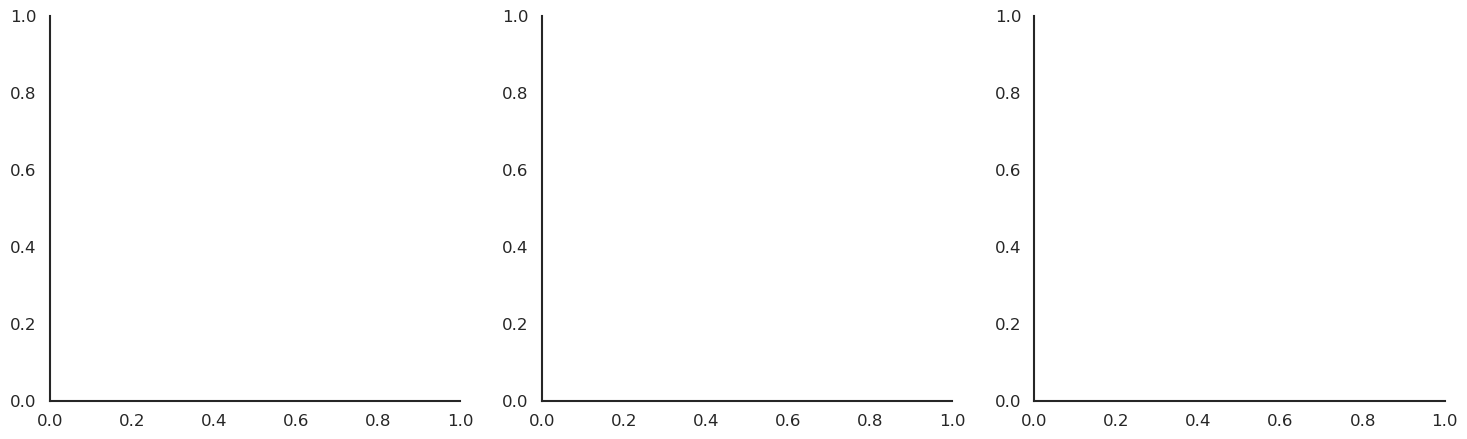

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import numpy as np
import os

# ============================================================
# PATHS
# ============================================================
csv_path = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data\result_df\all_foraging_data_07_02_24_with_PCL_factors.csv"

save_dir = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new"
os.makedirs(save_dir, exist_ok=True)

overall_fig_path = os.path.join(save_dir, "Figure4_combined_ABCD_from_all_foraging_data.png")
planet_fig_path = os.path.join(save_dir, "Figure4_by_planet_type_ABCD_from_all_foraging_data.png")
stats_csv_path = os.path.join(save_dir, "Figure4_scatter_stats_from_all_foraging_data.csv")

# ============================================================
# STYLE
# ============================================================
sns.set_style("white")

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 13,
    "axes.labelsize": 18,
    "axes.titlesize": 14,
    "axes.labelweight": "normal",
    "axes.titleweight": "normal",
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.5,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_csv(csv_path)

print("Loaded dataframe shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# ============================================================
# REQUIRED COLUMNS
# ============================================================
required_cols = [
    "sub_num",
    "FA_factor_1",
    "gamma_coef",
    "gamma_base",
    "prt_avg_rel_mvt",
    "prt_avg_rel_mvt_poor",
    "prt_avg_rel_mvt_mid",
    "prt_avg_rel_mvt_rich"
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# ============================================================
# CLEAN / KEEP NEEDED COLUMNS NUMERIC
# ============================================================
numeric_cols = [
    "sub_num",
    "FA_factor_1",
    "gamma_coef",
    "gamma_base",
    "prt_avg_rel_mvt",
    "prt_avg_rel_mvt_poor",
    "prt_avg_rel_mvt_mid",
    "prt_avg_rel_mvt_rich"
]

plot_df = df.copy()

for c in numeric_cols:
    plot_df[c] = pd.to_numeric(plot_df[c], errors="coerce")

plot_df = plot_df.replace([np.inf, -np.inf], np.nan)

print("\nNon-missing counts for key columns:")
for c in numeric_cols:
    print(f"{c}: {plot_df[c].notna().sum()}")

# ============================================================
# HELPERS
# ============================================================
def style_axes(ax):
    ax.set_facecolor("white")
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.5)

    ax.tick_params(axis="both", colors="black", width=1.5)


def add_label(ax, label):
    ax.text(
        0.01, 1.06, label,
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontsize=26,
        fontweight="normal"
    )


def prep_xy(data, x, y):
    clean = data[[x, y]].copy()
    clean[x] = pd.to_numeric(clean[x], errors="coerce")
    clean[y] = pd.to_numeric(clean[y], errors="coerce")
    clean = clean.replace([np.inf, -np.inf], np.nan).dropna()
    return clean


def get_corr_stats(data, x, y):
    clean = prep_xy(data, x, y)

    if len(clean) < 3:
        return None, clean

    pear_r, pear_p = pearsonr(clean[x], clean[y])
    spear_r, spear_p = spearmanr(clean[x], clean[y])

    stats = {
         "n": len(clean),
        "pearson_r": pear_r,
        "pearson_p": pear_p,
        "spearman_rho": spear_r,
        "spearman_p": spear_p
    }
    return stats, clean


def plot_panel(ax, data, x, y, xlabel, ylabel, color, header=""):
    stats, clean = get_corr_stats(data, x, y)

    if stats is None:
        ax.text(
            0.5, 0.5, "Not enough data",
            transform=ax.transAxes,
            ha="center", va="center", fontsize=13
        )
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        style_axes(ax)
        return None

    # scatter
    ax.scatter(
        clean[x], clean[y],
        s=38, alpha=0.8,
        edgecolor="black", linewidth=0.5,
        color=color
    )

    # fitted line
    coef = np.polyfit(clean[x], clean[y], 1)
    xx = np.linspace(clean[x].min(), clean[x].max(), 100)
    yy = np.polyval(coef, xx)
    ax.plot(xx, yy, color=color, linewidth=2.2)

    title = (
        f"r={stats['spearman_rho']:.2f}, p={stats['spearman_p']:.2g}"
    )
    ax.set_title(title, pad=8, fontsize=11)

    ax.set_xlabel(xlabel, fontweight="normal")
    ax.set_ylabel(ylabel, fontweight="normal")
    style_axes(ax)

    return stats


# ============================================================
# OVERALL FIGURE: A / B / C / D
# ============================================================
# A: ELU Factor 1 vs gamma_coef
# B: Overall overharvesting vs gamma_base
# C: Overall overharvesting vs gamma_coef
# D: ELU Factor 1 vs overall overharvesting
# ============================================================

# ---------- Pretty math labels ----------
GAMMA_BASE_LABEL = r"$\gamma_{\mathrm{base}}$"
GAMMA_COEF_LABEL = r"$\gamma_{\mathrm{coef}}$"

stats_rows = []

overall_specs = [
    {
        "panel_letter": "A.",
        "x": "FA_factor_1",
        "y": "gamma_coef",
        "xlabel": "ELU Factor 1",
        "ylabel": GAMMA_COEF_LABEL,
        "color": "#1f77b4",
        "panel_name": "overall_A_ELU_vs_gamma_coef"
    },
    {
        "panel_letter": "B.",
        "x": "prt_avg_rel_mvt",
        "y": "gamma_base",
        "xlabel": "Overharvesting (PRT - MVT)",
        "ylabel": GAMMA_BASE_LABEL,
        "color": "#1f77b4",
        "panel_name": "overall_B_overharvesting_vs_gamma_base"
    },
    {
        "panel_letter": "C.",
        "x": "prt_avg_rel_mvt",
        "y": "gamma_coef",
        "xlabel": "Overharvesting (PRT - MVT)",
        "ylabel": GAMMA_COEF_LABEL,
        "color": "#e41a1c",
        "panel_name": "overall_C_overharvesting_vs_gamma_coef"
    },
    # {
    #     "panel_letter": "D.",
    #     "x": "FA_factor_1",
    #     "y": "prt_avg_rel_mvt",
    #     "xlabel": "ELU Factor 1",
    #     "ylabel": "Overharvesting (PRT - MVT)",
    #     "color": "#2ca02c",
    #     "header": "Overall",
    #     "panel_name": "overall_D_ELU_vs_overharvesting"
    # }
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor("white")
axes = axes.flatten()

for ax, spec in zip(axes, overall_specs):
    out = plot_panel(
        ax=ax,
        data=plot_df,
        x=spec["x"],
        y=spec["y"],
        xlabel=spec["xlabel"],
        ylabel=spec["ylabel"],
        color=spec["color"],
        header=spec["header"]
    )
    add_label(ax, spec["panel_letter"])

    row = {
        "subset": "overall",
        "panel": spec["panel_name"],
        "x": spec["x"],
        "y": spec["y"]
    }
    if out is not None:
        row.update(out)
    stats_rows.append(row)

plt.tight_layout()
plt.savefig(overall_fig_path, dpi=400, bbox_inches="tight", facecolor="white")
plt.show()

print(f"\n🎉 Saved overall figure to:\n{overall_fig_path}")



### Figure 5 PCL ELU Mediation


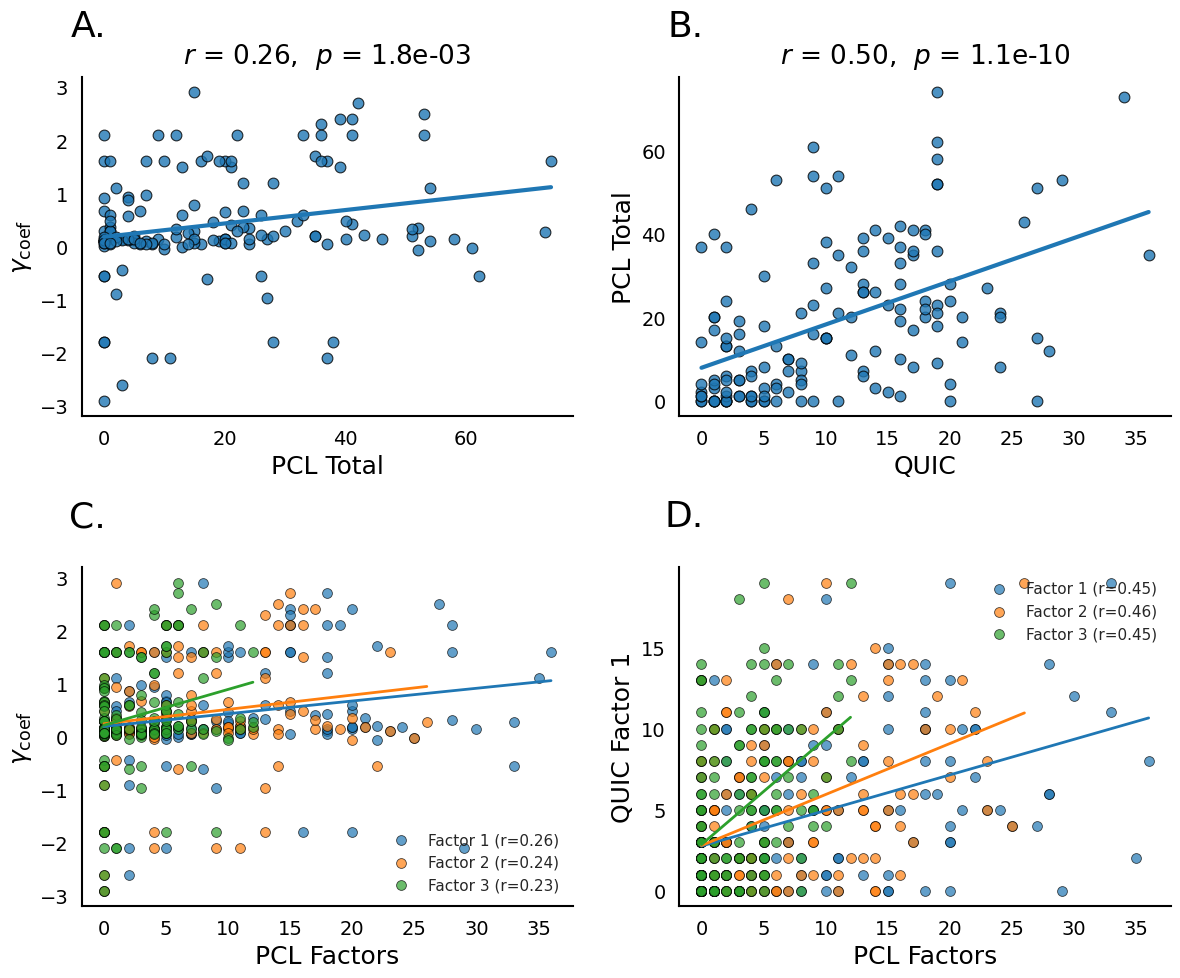

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import seaborn as sns

# =========================
# STYLE (publication)
# =========================
sns.set_style("white")

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 13,
    "axes.labelsize": 18,
    "axes.titlesize": 19,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.5,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
})

# =========================
# HELPERS
# =========================
def style_axes(ax):
    ax.set_facecolor("white")
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.5)

    ax.tick_params(axis='both', colors='black', width=1.5)

    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.title.set_color("black")


def scatter_with_reg(ax, x, y, xlabel, ylabel, color="tab:blue"):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)

    mask = ~np.isnan(x) & ~np.isnan(y)
    x, y = x[mask], y[mask]

    if len(x) < 2:
        ax.text(0.5, 0.5, "Not enough data", ha="center", va="center",
                transform=ax.transAxes, fontsize=14)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        style_axes(ax)
        return

    r, p = spearmanr(x, y)

    # scatter
    ax.scatter(
        x, y,
        s=60,
        alpha=0.8,
        edgecolor="black",
        linewidth=0.8,
        color=color
    )

    # regression
    coef = np.polyfit(x, y, 1)
    xx = np.linspace(x.min(), x.max(), 100)
    ax.plot(xx, np.polyval(coef, xx), color=color, linewidth=3)

    ax.set_xlabel(xlabel, fontweight='normal')
    ax.set_ylabel(ylabel, fontweight='normal')

    # stats
    ax.set_title(f"$r$ = {r:.2f},  $p$ = {p:.1e}", pad=10, fontweight='normal')

    style_axes(ax)


def add_label(ax, label):
    ax.text(
        0.05, 1.2
        , label,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=26, color="black"
    )


def multi_factor_plot(ax, y, factors, ylabel):
    colors = ["tab:blue", "tab:orange", "tab:green"]
    names = ["Factor 1", "Factor 2", "Factor 3"]

    plotted_any = False

    for f, c, name in zip(factors, colors, names):
        x = np.array(f, dtype=float)
        yy = np.array(y, dtype=float)

        mask = ~np.isnan(x) & ~np.isnan(yy)
        x = x[mask]
        yy = yy[mask]

        if len(x) < 2:
            continue

        plotted_any = True
        r, p = spearmanr(x, yy)

        ax.scatter(
            x, yy,
            s=50,
            alpha=0.7,
            color=c,
            edgecolor="black",
            linewidth=0.6,
            label=f"{name} (r={r:.2f})"
        )

        coef = np.polyfit(x, yy, 1)
        xx = np.linspace(x.min(), x.max(), 100)
        ax.plot(xx, np.polyval(coef, xx), color=c, linewidth=2)

    ax.set_xlabel("PCL Factors",fontweight='normal')
    ax.set_ylabel(ylabel,fontweight='normal')

    if plotted_any:
        ax.legend(frameon=False)
    else:
        ax.text(0.5, 0.5, "Not enough data", ha="center", va="center",
                transform=ax.transAxes, fontsize=14)

    style_axes(ax)


# =========================
# DATA
# =========================
gamma_coef = df["gamma_coef"]
PCL = df["PCL_Total"]
QUIC = df["QUIC"]

F1 = df["Factor_1"]
F2 = df["Factor_2"]
F3 = df["Factor_3"]

FA1 = df["FA_factor_1"] if "FA_factor_1" in df.columns else None


# =========================
# 2×2 FIGURE
# =========================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.patch.set_facecolor("white")

for ax in axes.flat:
    ax.set_facecolor("white")

# ---- A ----
scatter_with_reg(
    axes[0, 0],
    PCL, gamma_coef,
    "PCL Total", r"$\gamma_{\mathrm{coef}}$"
)
add_label(axes[0, 0], "A.")

# ---- B ----
scatter_with_reg(
    axes[0, 1],
    QUIC, PCL,
    "QUIC", "PCL Total"
)
add_label(axes[0, 1], "B.")

# ---- C ----
multi_factor_plot(
    axes[1, 0],
    gamma_coef,
    [F1, F2, F3],
    r"$\gamma_{\mathrm{coef}}$"
)
add_label(axes[1, 0], "C.")

# ---- D ----
if FA1 is not None:
    multi_factor_plot(
        axes[1, 1],
        FA1,
        [F1, F2, F3],
        "QUIC Factor 1"
    )
    add_label(axes[1, 1], "D.")
else:
    axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

## Correlation between PCL, gamma_coef, ELU

In [10]:
import os
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

# ============================================================
# SETTINGS
# ============================================================

save_dir = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new"
os.makedirs(save_dir, exist_ok=True)

elu_var = "FA_factor_1"

# ============================================================
# AUTO-DETECT PCL FACTOR COLUMNS
# ============================================================

candidate_sets = [
    ["Factor_1", "Factor_2", "Factor_3"],
    ["PCL_Factor_1", "PCL_Factor_2", "PCL_Factor_3"],
    ["PCL_factor_1", "PCL_factor_2", "PCL_factor_3"],
    ["pcl_factor_1", "pcl_factor_2", "pcl_factor_3"],
]

pcl_factors = None

for candidates in candidate_sets:
    if all(c in df.columns for c in candidates):
        pcl_factors = candidates
        break

if pcl_factors is None:
    print("\n❌ Could not detect PCL factor columns.")
    print("\nColumns containing 'factor':")
    print([c for c in df.columns if "factor" in c.lower()])
    raise ValueError("Please manually specify pcl_factors.")

print("\nUsing PCL factors:", pcl_factors)

# ============================================================
# ANALYSIS A:
# POOLED ELU ↔ PCL FACTOR CORRELATIONS
# ============================================================

pooled_results = []

print("\n===================================================")
print("POOLED ANALYSIS: ELU Factor 1 vs PCL Factors")
print("===================================================\n")

for pcl in pcl_factors:

    clean = df[[elu_var, pcl]].copy()

    clean[elu_var] = pd.to_numeric(clean[elu_var], errors="coerce")
    clean[pcl] = pd.to_numeric(clean[pcl], errors="coerce")

    clean = clean.replace([np.inf, -np.inf], np.nan).dropna()

    n = len(clean)

    if n < 3:
        continue

    pear_r, pear_p = pearsonr(clean[elu_var], clean[pcl])
    spear_rho, spear_p = spearmanr(clean[elu_var], clean[pcl])

    pooled_results.append({
        "analysis": "pooled",
        "PCL_factor": pcl,
        "n": n,
        "pearson_r": pear_r,
        "pearson_p": pear_p,
        "spearman_rho": spear_rho,
        "spearman_p": spear_p
    })

    print(f"{elu_var} vs {pcl}")
    print(f"  N = {n}")
    print(f"  Pearson:  r   = {pear_r:.4f},  p = {pear_p:.4g}")
    print(f"  Spearman: rho = {spear_rho:.4f},  p = {spear_p:.4g}")
    print("---------------------------------------------------")


# ============================================================
# ANALYSIS B:
# PLANET-TYPE SPECIFIC ANALYSIS
# ============================================================

planet_map = {
    "poor": "prt_avg_rel_mvt_poor",
    "mid": "prt_avg_rel_mvt_mid",
    "rich": "prt_avg_rel_mvt_rich"
}

planet_results = []

print("\n===================================================")
print("PLANET-TYPE ANALYSIS")
print("ELU Factor 1 vs PCL Factors")
print("===================================================\n")

for planet_name, prt_col in planet_map.items():

    print(f"\n#################### {planet_name.upper()} ####################\n")

    for pcl in pcl_factors:

        needed_cols = [elu_var, pcl, prt_col]

        clean = df[needed_cols].copy()

        for c in needed_cols:
            clean[c] = pd.to_numeric(clean[c], errors="coerce")

        clean = clean.replace([np.inf, -np.inf], np.nan).dropna()

        n = len(clean)

        if n < 3:
            continue

        pear_r, pear_p = pearsonr(clean[elu_var], clean[pcl])
        spear_rho, spear_p = spearmanr(clean[elu_var], clean[pcl])

        planet_results.append({
            "analysis": "planet_specific",
            "planet_type": planet_name,
            "PCL_factor": pcl,
            "n": n,
            "pearson_r": pear_r,
            "pearson_p": pear_p,
            "spearman_rho": spear_rho,
            "spearman_p": spear_p
        })

        print(f"{elu_var} vs {pcl}")
        print(f"  N = {n}")
        print(f"  Pearson:  r   = {pear_r:.4f},  p = {pear_p:.4g}")
        print(f"  Spearman: rho = {spear_rho:.4f},  p = {spear_p:.4g}")
        print("---------------------------------------------------")


# ============================================================
# SAVE RESULTS
# ============================================================

pooled_df = pd.DataFrame(pooled_results)
planet_df = pd.DataFrame(planet_results)

pooled_path = os.path.join(
    save_dir,
    "ELU_vs_PCL_factor_pooled_stats.csv"
)

planet_path = os.path.join(
    save_dir,
    "ELU_vs_PCL_factor_planettype_stats.csv"
)

pooled_df.to_csv(pooled_path, index=False)
planet_df.to_csv(planet_path, index=False)

print("\n===================================================")
print("✅ SAVED RESULTS")
print("===================================================")
print("Pooled stats:")
print(pooled_path)

print("\nPlanet-type stats:")
print(planet_path)




Using PCL factors: ['Factor_1', 'Factor_2', 'Factor_3']

POOLED ANALYSIS: ELU Factor 1 vs PCL Factors

FA_factor_1 vs Factor_1
  N = 147
  Pearson:  r   = 0.4243,  p = 8.519e-08
  Spearman: rho = 0.4541,  p = 7.635e-09
---------------------------------------------------
FA_factor_1 vs Factor_2
  N = 147
  Pearson:  r   = 0.4448,  p = 1.654e-08
  Spearman: rho = 0.4643,  p = 3.148e-09
---------------------------------------------------
FA_factor_1 vs Factor_3
  N = 147
  Pearson:  r   = 0.4534,  p = 8.046e-09
  Spearman: rho = 0.4499,  p = 1.084e-08
---------------------------------------------------

PLANET-TYPE ANALYSIS
ELU Factor 1 vs PCL Factors


#################### POOR ####################

FA_factor_1 vs Factor_1
  N = 147
  Pearson:  r   = 0.4243,  p = 8.519e-08
  Spearman: rho = 0.4541,  p = 7.635e-09
---------------------------------------------------
FA_factor_1 vs Factor_2
  N = 147
  Pearson:  r   = 0.4448,  p = 1.654e-08
  Spearman: rho = 0.4643,  p = 3.148e-09
--------

In [6]:
df['prt_avg_rel_mvt']

0      5.9
1      3.7
2      9.2
3      5.1
4      2.7
      ... 
292    1.6
293   -2.4
294   -1.2
295    7.7
296    1.4
Name: prt_avg_rel_mvt, Length: 297, dtype: float64

## ELU gamma coef OVERHARVESTING mediation

In [12]:
# ============================================================
# ANALYSIS 2:
# Subject-level mediation analysis
#
# X  = ELU Factor 1
# M1 = gamma_coef
# M2 = gamma_base
# Y  = aggregate overharvesting = prt_avg_rel_mvt
#
# This version uses fileID as the unique subject identifier.
# It collapses duplicate fileID rows before mediation.
# ============================================================

import os
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import pearsonr, spearmanr

# ============================================================
# SETTINGS
# ============================================================

ID = "fileID"

X = "FA_factor_1"
M1 = "gamma_coef"
M2 = "gamma_base"
Y = "prt_avg_rel_mvt"   # already aggregate overharvesting in dataframe

N_BOOT = 200
SEED_SINGLE = 123
SEED_PARALLEL = 456

save_dir = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new"
os.makedirs(save_dir, exist_ok=True)


# ============================================================
# BASIC COLUMN CHECK
# ============================================================

needed_cols = [ID, X, M1, M2, Y]
missing_cols = [c for c in needed_cols if c not in df.columns]

if missing_cols:
    raise ValueError(f"Missing columns in df: {missing_cols}")

print("\n===================================================")
print("RAW DATA CHECK")
print("===================================================")
print("Raw rows:", len(df))
print("Unique fileID:", df[ID].nunique())
print("Duplicate fileID rows:", df.duplicated(subset=[ID]).sum())

print("\nNon-missing counts before collapsing:")
for c in needed_cols:
    print(f"{c}: {df[c].notna().sum()}")


# ============================================================
# BUILD SUBJECT-LEVEL DATAFRAME USING fileID
# ============================================================

base = df[needed_cols].copy()

# Convert analysis variables to numeric
for col in [X, M1, M2, Y]:
    base[col] = pd.to_numeric(base[col], errors="coerce")

base = base.replace([np.inf, -np.inf], np.nan)

# ------------------------------------------------------------
# Collapse duplicate fileID rows.
#
# Since X, gamma parameters, and prt_avg_rel_mvt should be subject-level
# variables, duplicates should usually have identical values.
# Taking the mean is safe if duplicates are identical; if not, it gives
# a subject-level average.
# ------------------------------------------------------------

subject_df = (
    base
    .groupby(ID, as_index=False)
    .agg({
        X: "mean",
        M1: "mean",
        M2: "mean",
        Y: "mean"
    })
)

subject_df = subject_df.rename(columns={Y: "overharvesting_avg"})

print("\n===================================================")
print("SUBJECT-LEVEL DATA AFTER COLLAPSING fileID")
print("===================================================")
print("N unique fileID:", subject_df[ID].nunique())
print("N rows:", len(subject_df))

print("\nNon-missing subject-level counts:")
for c in [X, M1, M2, "overharvesting_avg"]:
    print(f"{c}: {subject_df[c].notna().sum()}")

print("\nDescriptive statistics:")
print(subject_df[[X, M1, M2, "overharvesting_avg"]].describe())


# ============================================================
# OPTIONAL DUPLICATE CONSISTENCY CHECK
# ============================================================
# This checks whether duplicate fileID rows have inconsistent values.
# Large numbers here mean duplicate rows were not exact copies.

print("\n===================================================")
print("DUPLICATE CONSISTENCY CHECK")
print("Number of unique non-missing values per fileID")
print("If max > 1, duplicate rows differ for that variable.")
print("===================================================")

for col in [X, M1, M2, Y]:
    nunique_by_id = (
        base
        .dropna(subset=[col])
        .groupby(ID)[col]
        .nunique()
    )
    if len(nunique_by_id) > 0:
        print(f"{col}: max unique values within fileID = {nunique_by_id.max()}")
    else:
        print(f"{col}: all missing")


# ============================================================
# CREATE COMPLETE-CASE DATASETS
# ============================================================
# Single mediation does not require gamma_base.
# Parallel mediation does require gamma_base.

med_df_single = subject_df.dropna(
    subset=[ID, X, M1, "overharvesting_avg"]
).copy()

med_df_parallel = subject_df.dropna(
    subset=[ID, X, M1, M2, "overharvesting_avg"]
).copy()

print("\n===================================================")
print("FINAL MEDIATION SAMPLE SIZES")
print("===================================================")
print("Single mediation N:", med_df_single[ID].nunique())
print("Parallel mediation N:", med_df_parallel[ID].nunique())


# ============================================================
# BASIC SUBJECT-LEVEL CORRELATION CHECKS
# ============================================================

def print_corrs(data, label):
    print("\n===================================================")
    print(label)
    print("===================================================")

    for var in [M1, M2, "overharvesting_avg"]:
        if var not in data.columns:
            continue

        clean = data[[X, var]].dropna()

        if len(clean) < 3:
            print(f"\n{X} vs {var}: not enough data")
            continue

        pear_r, pear_p = pearsonr(clean[X], clean[var])
        spear_r, spear_p = spearmanr(clean[X], clean[var])

        print(f"\n{X} vs {var}")
        print(f"  N = {len(clean)}")
        print(f"  Pearson:  r   = {pear_r:.4f}, p = {pear_p:.4g}")
        print(f"  Spearman: rho = {spear_r:.4f}, p = {spear_p:.4g}")


print_corrs(subject_df, "SUBJECT-LEVEL CORRELATION CHECKS")


# ============================================================
# HELPERS
# ============================================================

def pct_ci(arr, alpha=0.05):
    arr = np.asarray(arr, dtype=float)
    arr = arr[np.isfinite(arr)]

    if len(arr) == 0:
        return np.nan, np.nan

    return (
        np.percentile(arr, 100 * alpha / 2),
        np.percentile(arr, 100 * (1 - alpha / 2))
    )


def bootstrap_subject_df(subject_df, rng):
    """
    Subject-level bootstrap.
    Resamples fileID rows with replacement.
    """
    idx = rng.choice(subject_df.index.to_numpy(), size=len(subject_df), replace=True)
    return subject_df.loc[idx].copy().reset_index(drop=True)


# ============================================================
# SINGLE MEDIATION:
# X -> gamma_coef -> aggregate overharvesting
# ============================================================

def subject_single_mediation(subject_df, x, m, y="overharvesting_avg",
                              id_col="fileID", n_boot=5000, seed=123):

    rng = np.random.default_rng(seed)

    # Main path models
    mod_a = smf.ols(f"{m} ~ {x}", data=subject_df).fit()
    mod_b = smf.ols(f"{y} ~ {x} + {m}", data=subject_df).fit()
    mod_c = smf.ols(f"{y} ~ {x}", data=subject_df).fit()

    a = mod_a.params[x]
    b = mod_b.params[m]
    c_total = mod_c.params[x]
    c_prime = mod_b.params[x]
    indirect = a * b

    boot_ind = []
    boot_c_total = []
    boot_c_prime = []

    for _ in range(n_boot):
        bs = bootstrap_subject_df(subject_df, rng)

        try:
            mod_a_bs = smf.ols(f"{m} ~ {x}", data=bs).fit()
            mod_b_bs = smf.ols(f"{y} ~ {x} + {m}", data=bs).fit()
            mod_c_bs = smf.ols(f"{y} ~ {x}", data=bs).fit()

            a_bs = mod_a_bs.params[x]
            b_bs = mod_b_bs.params[m]

            boot_ind.append(a_bs * b_bs)
            boot_c_total.append(mod_c_bs.params[x])
            boot_c_prime.append(mod_b_bs.params[x])

        except Exception:
            continue

    ci_ind = pct_ci(boot_ind)
    ci_c_total = pct_ci(boot_c_total)
    ci_c_prime = pct_ci(boot_c_prime)

    return {
        "N_subjects": int(subject_df[id_col].nunique()),
        "N_rows": int(len(subject_df)),

        "a": a,
        "a_p": mod_a.pvalues[x],

        "b": b,
        "b_p": mod_b.pvalues[m],

        "c_total": c_total,
        "c_total_p": mod_c.pvalues[x],
        "c_total_ci_lo": ci_c_total[0],
        "c_total_ci_hi": ci_c_total[1],

        "c_prime": c_prime,
        "c_prime_p": mod_b.pvalues[x],
        "c_prime_ci_lo": ci_c_prime[0],
        "c_prime_ci_hi": ci_c_prime[1],

        "indirect_ab": indirect,
        "indirect_ci_lo": ci_ind[0],
        "indirect_ci_hi": ci_ind[1],

        "prop_mediated": indirect / c_total if c_total != 0 else np.nan,

        "n_boot_requested": int(n_boot),
        "n_boot_successful": int(len(boot_ind))
    }


# ============================================================
# PARALLEL MEDIATION:
# X -> [gamma_coef, gamma_base] -> aggregate overharvesting
# ============================================================

def subject_parallel_mediation(subject_df, x, m1, m2, y="overharvesting_avg",
                                id_col="fileID", n_boot=5000, seed=456):

    rng = np.random.default_rng(seed)

    # Main path models
    mod_a1 = smf.ols(f"{m1} ~ {x}", data=subject_df).fit()
    mod_a2 = smf.ols(f"{m2} ~ {x}", data=subject_df).fit()

    mod_y = smf.ols(f"{y} ~ {x} + {m1} + {m2}", data=subject_df).fit()
    mod_c = smf.ols(f"{y} ~ {x}", data=subject_df).fit()

    a1 = mod_a1.params[x]
    a2 = mod_a2.params[x]

    b1 = mod_y.params[m1]
    b2 = mod_y.params[m2]

    ind1 = a1 * b1
    ind2 = a2 * b2
    ind_total = ind1 + ind2

    c_total = mod_c.params[x]
    c_prime = mod_y.params[x]

    boot_ind1 = []
    boot_ind2 = []
    boot_total = []
    boot_c_total = []
    boot_c_prime = []

    for _ in range(n_boot):
        bs = bootstrap_subject_df(subject_df, rng)

        try:
            mod_a1_bs = smf.ols(f"{m1} ~ {x}", data=bs).fit()
            mod_a2_bs = smf.ols(f"{m2} ~ {x}", data=bs).fit()
            mod_y_bs = smf.ols(f"{y} ~ {x} + {m1} + {m2}", data=bs).fit()
            mod_c_bs = smf.ols(f"{y} ~ {x}", data=bs).fit()

            a1_bs = mod_a1_bs.params[x]
            a2_bs = mod_a2_bs.params[x]
            b1_bs = mod_y_bs.params[m1]
            b2_bs = mod_y_bs.params[m2]

            i1 = a1_bs * b1_bs
            i2 = a2_bs * b2_bs

            boot_ind1.append(i1)
            boot_ind2.append(i2)
            boot_total.append(i1 + i2)
            boot_c_total.append(mod_c_bs.params[x])
            boot_c_prime.append(mod_y_bs.params[x])

        except Exception:
            continue

    ci1 = pct_ci(boot_ind1)
    ci2 = pct_ci(boot_ind2)
    ci_total = pct_ci(boot_total)
    ci_c_total = pct_ci(boot_c_total)
    ci_c_prime = pct_ci(boot_c_prime)

    return {
        "N_subjects": int(subject_df[id_col].nunique()),
        "N_rows": int(len(subject_df)),

        "a_gamma_coef": a1,
        "a_gamma_coef_p": mod_a1.pvalues[x],

        "a_gamma_base": a2,
        "a_gamma_base_p": mod_a2.pvalues[x],

        "b_gamma_coef": b1,
        "b_gamma_coef_p": mod_y.pvalues[m1],

        "b_gamma_base": b2,
        "b_gamma_base_p": mod_y.pvalues[m2],

        "c_total": c_total,
        "c_total_p": mod_c.pvalues[x],
        "c_total_ci_lo": ci_c_total[0],
        "c_total_ci_hi": ci_c_total[1],

        "c_prime": c_prime,
        "c_prime_p": mod_y.pvalues[x],
        "c_prime_ci_lo": ci_c_prime[0],
        "c_prime_ci_hi": ci_c_prime[1],

        "indirect_gamma_coef": ind1,
        "indirect_gamma_coef_ci_lo": ci1[0],
        "indirect_gamma_coef_ci_hi": ci1[1],

        "indirect_gamma_base": ind2,
        "indirect_gamma_base_ci_lo": ci2[0],
        "indirect_gamma_base_ci_hi": ci2[1],

        "indirect_total": ind_total,
        "indirect_total_ci_lo": ci_total[0],
        "indirect_total_ci_hi": ci_total[1],

        "prop_mediated_total": ind_total / c_total if c_total != 0 else np.nan,

        "n_boot_requested": int(n_boot),
        "n_boot_successful": int(len(boot_total))
    }


# ============================================================
# RUN SUBJECT-LEVEL MEDIATION MODELS
# ============================================================

single_subject = subject_single_mediation(
    med_df_single,
    x=X,
    m=M1,
    y="overharvesting_avg",
    id_col=ID,
    n_boot=N_BOOT,
    seed=SEED_SINGLE
)

parallel_subject = subject_parallel_mediation(
    med_df_parallel,
    x=X,
    m1=M1,
    m2=M2,
    y="overharvesting_avg",
    id_col=ID,
    n_boot=N_BOOT,
    seed=SEED_PARALLEL
)


# ============================================================
# PRINT RESULTS
# ============================================================

def print_results(title, results):
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)

    for k, v in results.items():
        if isinstance(v, float):
            print(f"{k}: {v:.6f}")
        else:
            print(f"{k}: {v}")


print_results(
    "SUBJECT-LEVEL SINGLE MEDIATION: ELU Factor 1 → gamma_coef → aggregate overharvesting",
    single_subject
)

print_results(
    "SUBJECT-LEVEL PARALLEL MEDIATION: ELU Factor 1 → [gamma_coef, gamma_base] → aggregate overharvesting",
    parallel_subject
)


# ============================================================
# SAVE RESULTS
# ============================================================

single_subject_df = pd.DataFrame([single_subject])
parallel_subject_df = pd.DataFrame([parallel_subject])

single_path = os.path.join(
    save_dir,
    "subject_level_mediation_single_gamma_coef_fileID.csv"
)

parallel_path = os.path.join(
    save_dir,
    "subject_level_mediation_parallel_gamma_coef_gamma_base_fileID.csv"
)

analysis_data_path = os.path.join(
    save_dir,
    "subject_level_mediation_analysis_dataframe_fileID.csv"
)

single_subject_df.to_csv(single_path, index=False)
parallel_subject_df.to_csv(parallel_path, index=False)
subject_df.to_csv(analysis_data_path, index=False)

print("\n===================================================")
print("SAVED SUBJECT-LEVEL MEDIATION RESULTS")
print("===================================================")
print("Single mediation:")
print(single_path)
print("\nParallel mediation:")
print(parallel_path)
print("\nAnalysis dataframe:")
print(analysis_data_path)


RAW DATA CHECK
Raw rows: 297
Unique fileID: 297
Duplicate fileID rows: 0

Non-missing counts before collapsing:
fileID: 297
FA_factor_1: 297
gamma_coef: 297
gamma_base: 297
prt_avg_rel_mvt: 297

SUBJECT-LEVEL DATA AFTER COLLAPSING fileID
N unique fileID: 297
N rows: 297

Non-missing subject-level counts:
FA_factor_1: 297
gamma_coef: 297
gamma_base: 297
overharvesting_avg: 297

Descriptive statistics:
       FA_factor_1  gamma_coef  gamma_base  overharvesting_avg
count   297.000000  297.000000  297.000000          297.000000
mean      4.242424    0.451909    1.845624            1.290529
std       4.798840    0.987372    3.324222            2.127812
min       0.000000   -2.900000   -2.000000           -2.800000
25%       0.000000    0.070000   -0.140000            0.062000
50%       3.000000    0.170000    0.860000            0.780000
75%       7.000000    0.910000    2.800000            2.200000
max      19.000000    2.900000   10.000000           11.000000

DUPLICATE CONSISTENCY CHECK

## ELU x PCL factors Regression and Mediation Analysis

Analysis N = 147

REGRESSION 1: gamma_coef ~ ELU Factor 1 + PCL Total
Standardized coefficients

                            OLS Regression Results                            
Dep. Variable:           z_gamma_coef   R-squared:                       0.097
Model:                            OLS   Adj. R-squared:                  0.085
Method:                 Least Squares   F-statistic:                     7.771
Date:                Sun, 24 May 2026   Prob (F-statistic):           0.000624
Time:                        12:27:59   Log-Likelihood:                -201.05
No. Observations:                 147   AIC:                             408.1
Df Residuals:                     144   BIC:                             417.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

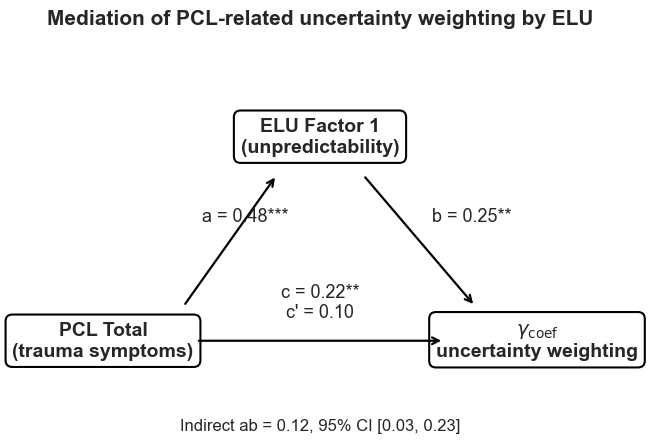


Saved mediation path figure to:
C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new\PCL_ELU_gamma_coef_mediation_path_plot.png


In [ ]:
# ============================================================
# ELU vs PCL: regression isolation + mediation/path plot
# Assumes df is already loaded
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# -----------------------------
# Paths
# -----------------------------
save_dir = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new"
os.makedirs(save_dir, exist_ok=True)

# -----------------------------
# Variables
# -----------------------------
ELU = "FA_factor_1"
PCL_TOTAL = "PCL_Total"
Y = "gamma_coef"

PCL_FACTORS = ["Factor_1", "Factor_2", "Factor_3"]

required = [ELU, PCL_TOTAL, Y] + PCL_FACTORS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# ============================================================
# Helper functions
# ============================================================

def zscore(s):
    s = pd.to_numeric(s, errors="coerce")
    return (s - s.mean()) / s.std(ddof=0)

def stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

def fmt_p(p):
    if p < 0.001:
        return "p < .001"
    else:
        return f"p = {p:.3f}"

def pct_ci(arr, alpha=0.05):
    return (
        np.percentile(arr, 100 * alpha / 2),
        np.percentile(arr, 100 * (1 - alpha / 2))
    )

# ============================================================
# 1. Prepare standardized analysis dataframe
# ============================================================

analysis_cols = [ELU, PCL_TOTAL, Y] + PCL_FACTORS
d = df[analysis_cols].copy().replace([np.inf, -np.inf], np.nan)

for c in analysis_cols:
    d[c] = pd.to_numeric(d[c], errors="coerce")

d = d.dropna()

for c in analysis_cols:
    d[f"z_{c}"] = zscore(d[c])

print(f"Analysis N = {len(d)}")

# ============================================================
# 2. Regression isolation test:
# gamma_coef ~ ELU + PCL Total
# ============================================================

m_total = smf.ols(
    f"z_{Y} ~ z_{ELU} + z_{PCL_TOTAL}",
    data=d
).fit()

print("\n===================================================")
print("REGRESSION 1: gamma_coef ~ ELU Factor 1 + PCL Total")
print("Standardized coefficients")
print("===================================================\n")
print(m_total.summary())

# Extract concise stats
reg1 = pd.DataFrame({
    "predictor": m_total.params.index,
    "beta": m_total.params.values,
    "p": m_total.pvalues.values,
    "t": m_total.tvalues.values
})

print("\nConcise regression table:")
print(reg1.round(4))

# ============================================================
# 3. Regression isolation test:
# gamma_coef ~ ELU + PCL Factors
# ============================================================

formula_factors = (
    f"z_{Y} ~ z_{ELU} + "
    + " + ".join([f"z_{f}" for f in PCL_FACTORS])
)

m_factors = smf.ols(formula_factors, data=d).fit()

print("\n===================================================")
print("REGRESSION 2: gamma_coef ~ ELU Factor 1 + PCL Factors")
print("Standardized coefficients")
print("===================================================\n")
print(m_factors.summary())

reg2 = pd.DataFrame({
    "predictor": m_factors.params.index,
    "beta": m_factors.params.values,
    "p": m_factors.pvalues.values,
    "t": m_factors.tvalues.values
})

print("\nConcise regression table:")
print(reg2.round(4))

# Save regression tables
reg1_path = os.path.join(save_dir, "ELU_PCL_total_unique_regression_gamma_coef.csv")
reg2_path = os.path.join(save_dir, "ELU_PCL_factor_unique_regression_gamma_coef.csv")

reg1.to_csv(reg1_path, index=False)
reg2.to_csv(reg2_path, index=False)

print(f"\nSaved regression 1 table to:\n{reg1_path}")
print(f"Saved regression 2 table to:\n{reg2_path}")

# ============================================================
# 4. Mediation model:
# PCL Total -> ELU Factor 1 -> gamma_coef
#
# This tests whether the apparent PCL-gamma_coef association
# is carried by shared variance with ELU.
# ============================================================

X = f"z_{PCL_TOTAL}"   # predictor
M = f"z_{ELU}"         # mediator
OUT = f"z_{Y}"         # outcome

# a path: ELU ~ PCL
mod_a = smf.ols(f"{M} ~ {X}", data=d).fit()

# b and c' paths: gamma_coef ~ PCL + ELU
mod_b = smf.ols(f"{OUT} ~ {X} + {M}", data=d).fit()

# total c path: gamma_coef ~ PCL
mod_c = smf.ols(f"{OUT} ~ {X}", data=d).fit()

a = mod_a.params[X]
a_p = mod_a.pvalues[X]

b = mod_b.params[M]
b_p = mod_b.pvalues[M]

c_total = mod_c.params[X]
c_total_p = mod_c.pvalues[X]

c_prime = mod_b.params[X]
c_prime_p = mod_b.pvalues[X]

indirect = a * b

# Bootstrap indirect effect
rng = np.random.default_rng(123)
boot_ind = []

for _ in range(5000):
    bs = d.sample(n=len(d), replace=True, random_state=int(rng.integers(0, 1e9)))

    try:
        a_bs = smf.ols(f"{M} ~ {X}", data=bs).fit().params[X]
        b_bs = smf.ols(f"{OUT} ~ {X} + {M}", data=bs).fit().params[M]
        boot_ind.append(a_bs * b_bs)
    except Exception:
        continue

boot_ind = np.array(boot_ind)
ci_lo, ci_hi = pct_ci(boot_ind)

med_stats = {
    "N": len(d),
    "a_PCL_to_ELU": a,
    "a_p": a_p,
    "b_ELU_to_gamma_coef_controlling_PCL": b,
    "b_p": b_p,
    "c_total_PCL_to_gamma_coef": c_total,
    "c_total_p": c_total_p,
    "c_prime_PCL_to_gamma_coef_controlling_ELU": c_prime,
    "c_prime_p": c_prime_p,
    "indirect_ab": indirect,
    "indirect_ci_lo": ci_lo,
    "indirect_ci_hi": ci_hi
}

med_df = pd.DataFrame([med_stats])

print("\n===================================================")
print("MEDIATION: PCL Total -> ELU Factor 1 -> gamma_coef")
print("Standardized path coefficients")
print("===================================================\n")

print(f"a path: PCL Total -> ELU Factor 1: beta = {a:.3f}, {fmt_p(a_p)}")
print(f"b path: ELU Factor 1 -> gamma_coef | PCL: beta = {b:.3f}, {fmt_p(b_p)}")
print(f"total effect c: PCL Total -> gamma_coef: beta = {c_total:.3f}, {fmt_p(c_total_p)}")
print(f"direct effect c': PCL Total -> gamma_coef | ELU: beta = {c_prime:.3f}, {fmt_p(c_prime_p)}")
print(f"indirect effect ab: {indirect:.3f}")
print(f"95% bootstrap CI: [{ci_lo:.3f}, {ci_hi:.3f}]")

med_path = os.path.join(save_dir, "PCL_ELU_gamma_coef_mediation_stats.csv")
med_df.to_csv(med_path, index=False)

print(f"\nSaved mediation stats to:\n{med_path}")



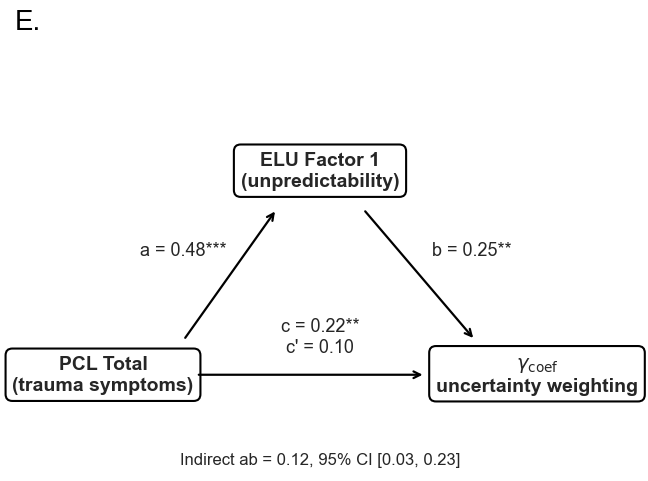


Saved mediation path figure to:
C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new\PCL_ELU_gamma_coef_mediation_path_plot.png


In [13]:
# ============================================================
# 5. Path plot figure
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))
ax.axis("off")

# Node positions
pos_X = (0.15, 0.25)
pos_M = (0.50, 0.78)
pos_Y = (0.85, 0.25)

# Draw nodes
node_kw = dict(
    ha="center", va="center",
    fontsize=14, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="black", linewidth=1.5)
)

ax.text(*pos_X, "PCL Total\n(trauma symptoms)", **node_kw)
ax.text(*pos_M, "ELU Factor 1\n(unpredictability)", **node_kw)
ax.text(*pos_Y, r"$\gamma_{\mathrm{coef}}$" + "\nuncertainty weighting", **node_kw)

# Arrow helper
def arrow(start, end):
    ax.annotate(
        "",
        xy=end, xytext=start,
        arrowprops=dict(arrowstyle="->", lw=1.6, color="black")
    )

# Arrows
arrow((0.28, 0.34), (0.43, 0.68))   # X -> M
arrow((0.57, 0.68), (0.75, 0.34))   # M -> Y
arrow((0.30, 0.25), (0.67, 0.25))   # X -> Y

# Labels
ax.text(
    0.21, 0.56,
    f"a = {a:.2f}{stars(a_p)}",
    fontsize=13
)

ax.text(
    0.68, 0.56,
    f"b = {b:.2f}{stars(b_p)}",
    fontsize=13
)

ax.text(
    0.50, 0.31,
    f"c = {c_total:.2f}{stars(c_total_p)}\n"
    f"c' = {c_prime:.2f}{stars(c_prime_p)}",
    fontsize=13,
    ha="center"
)

# Indirect effect annotation
if ci_lo > 0 or ci_hi < 0:
    indirect_txt = f"Indirect ab = {indirect:.2f}, 95% CI [{ci_lo:.2f}, {ci_hi:.2f}]"
else:
    indirect_txt = f"Indirect ab = {indirect:.2f}, 95% CI [{ci_lo:.2f}, {ci_hi:.2f}]"

ax.text(
    0.5, 0.03,
    indirect_txt,
    ha="center", va="center",
    fontsize=12
)

# ax.set_title(
#     "Mediation of PCL-related uncertainty weighting by ELU",
#     fontsize=15,
#     fontweight="bold",
#     pad=20
# )

def add_label(ax, label):
    ax.text(
        0.05, 1.2
        , label,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=20, color="black"
    )



add_label(ax, "E.")

fig_path = os.path.join(save_dir, "PCL_ELU_gamma_coef_mediation_path_plot.png")
plt.savefig(fig_path, dpi=500, bbox_inches="tight", facecolor="white")
plt.show()

print(f"\nSaved mediation path figure to:\n{fig_path}")

## QUIC factor Analysis

In [ ]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import statsmodels.formula.api as smf

# --------------------------------------------------------
# PARAMETERS
# --------------------------------------------------------
out_dir = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new\scatter_plots_age_groups"
os.makedirs(out_dir, exist_ok=True)

behavior_vars = [
    "Recognition", "MST_Score", "QUIC",
    "Parental_monitoring_and_involvement", "Parental_predictability",
    "Parental_environment", "Physical_environment", "Safety_and_security"
]

model_vars = ["alpha", "gamma_base", "gamma_coef"]

# Filter only columns that exist
behavior_vars = [b for b in behavior_vars if b in data.columns]
model_vars = [m for m in model_vars if m in data.columns]

# Age demarcation
AGE_CUTOFF = 50
data["AgeGroup"] = np.where(data["Age"] < AGE_CUTOFF, "Young", "Old")

print("\nUsing Age < 50 = Young, Age >= 50 = Old\n")

sns.set_theme(style="whitegrid")


# --------------------------------------------------------
# MAIN LOOP
# --------------------------------------------------------
for b in behavior_vars:
    for m in model_vars:

        print(f"\n=== {m} vs {b} ===")

        # Prepare pairwise dataset
        sub = data[[m, b, "Age", "AgeGroup"]].dropna()

        # Split groups
        young = sub[sub["AgeGroup"] == "Young"]
        old   = sub[sub["AgeGroup"] == "Old"]

        # Compute correlations
        def safe_corr(df):
            if len(df) < 3:
                return np.nan, np.nan
            return pearsonr(df[m], df[b])

        r_y, p_y = safe_corr(young)
        r_o, p_o = safe_corr(old)

        # --------------------------------------------------------
        # LINEAR MODEL: behavior ~ model_param + Age + interaction
        # --------------------------------------------------------
        formula = f"{b} ~ {m} + Age + {m}:Age"
        lm = smf.ols(formula=formula, data=sub).fit()

        print(lm.summary())


        # --------------------------------------------------------
        # PLOT
        # --------------------------------------------------------
        plt.figure(figsize=(7, 6))

        # Plot groups separately
        sns.regplot(data=young, x=m, y=b, scatter_kws={"s": 30},
                    label=f"Young (N={len(young)}, r={r_y:.2f}, p={p_y:.3g})",
                    color="blue")

        sns.regplot(data=old, x=m, y=b, scatter_kws={"s": 30},
                    label=f"Old (N={len(old)}, r={r_o:.2f}, p={p_o:.3g})",
                    color="red")

        plt.title(f"{m} vs {b}\nAge-Split Regression", fontsize=14, fontweight="bold")
        plt.xlabel(m)
        plt.ylabel(b)
        plt.legend()

        plt.tight_layout()

        # Save
        fname = f"{b}_vs_{m}_age_groups.png".replace(" ", "_")
        fpath = os.path.join(out_dir, fname)
        plt.savefig(fpath, dpi=300, bbox_inches="tight")
        plt.close()

        print(f"Saved plot: {fpath}")

print("\n🎉 All plots and regression results completed!")





### Effect of Age



import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import os

# --------------------------------------------------------
# Setup
# --------------------------------------------------------
behavior_vars = [
    "Recognition", "MST_Score", "QUIC",
    "Parental_monitoring_and_involvement", "Parental_predictability",
    "Parental_environment", "Physical_environment", "Safety_and_security"
]

model_vars = ["alpha", "gamma_base", "gamma_coef"]

# Keep only existing columns
behavior_vars = [b for b in behavior_vars if b in data.columns]
model_vars = [m for m in model_vars if m in data.columns]

# Storage
results = []

# --------------------------------------------------------
# Loop through all pairs and test moderation
# --------------------------------------------------------
for b in behavior_vars:
    for m in model_vars:

        # Pairwise dataset
        sub = data[[b, m, "Age"]].dropna()

        # Fit interaction model
        formula = f"{b} ~ {m} + Age + {m}:Age"
        lm = smf.ols(formula=formula, data=sub).fit()

        # Extract interaction p-value
        try:
            p_interaction = lm.pvalues[f"{m}:Age"]
        except KeyError:
            p_interaction = np.nan

        # Save
        results.append({
            "Behavior": b,
            "ModelParam": m,
            "Interaction_p": p_interaction,
            "N": len(sub)
        })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# --------------------------------------------------------
# Save CSV
# --------------------------------------------------------
out_csv = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data\result_df\age_moderation_results.csv"
results_df.to_csv(out_csv, index=False)

print(f"\n📄 Saved moderation table to:\n{out_csv}\n")

# --------------------------------------------------------
# Print significant moderators
# --------------------------------------------------------
sig_df = results_df[results_df["Interaction_p"] < 0.05]

print("🔥 === AGE SIGNIFICANTLY MODERATES THESE PAIRS (p < .05) ===")
if len(sig_df) == 0:
    print("❌ No significant moderation effects found.")
else:
    print(sig_df.to_string(index=False))
    
    
    



C:\Users\zyfxl\AppData\Local\Temp\ipykernel_42760\3473789251.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["AgeGroup"] = np.where(data["Age"] < AGE_CUTOFF, "Young", "Old")



Using Age < 50 = Young, Age >= 50 = Old


=== alpha vs Recognition ===
                            OLS Regression Results                            
Dep. Variable:            Recognition   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     2.428
Date:                Tue, 02 Dec 2025   Prob (F-statistic):             0.0671
Time:                        15:54:25   Log-Likelihood:                -17.800
No. Observations:                 180   AIC:                             43.60
Df Residuals:                     176   BIC:                             56.37
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

## Overharvesting Analysis

In [8]:
def string_to_lst(s):
    if ',' in s:
        return np.array(s[1:-1].split(',')).astype(float)
    elif s=='[]':
        return np.nan
    else:
        return np.array([s[1:-1]]).astype(float)

all_data = pd.read_csv('../data/semi_raw_data/all_foraging_data_massive_ae_07_02_24.csv')
all_data['rt_list'] = all_data['rt_list'].apply(string_to_lst)
all_data

,fileID,sub_num,condition,age,gender,n_prac,block,planet,true_planet,prt,...,gal_2_trans_1,gal_2_trans_2,gal_0_encount,gal_1_encount,gal_2_encount,opt_prt,opt_prt_om,prt_rel_mvt,prt_rel_om,expGroup
0,f0t6xrl6,1,2,NaN,female,2,1,0,0,5,...,NaN,NaN,1,0,0,2,2,3,3,new
1,f0t6xrl6,1,2,NaN,female,2,1,1,1,5,...,NaN,NaN,2,0,0,2,2,3,3,new
2,f0t6xrl6,1,2,NaN,female,2,1,2,2,9,...,NaN,NaN,2,1,0,2,3,7,6,new
3,f0t6xrl6,1,2,NaN,female,2,1,3,3,7,...,NaN,NaN,2,2,0,3,3,4,4,new
4,f0t6xrl6,1,2,NaN,female,2,1,4,4,8,...,NaN,NaN,2,3,0,3,3,5,5,new
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19950,5tmkmsdq,513,1,28.0,female,1,5,50,88,3,...,0.2,0.65,11,20,20,3,2,0,1,NH_MST
19951,5tmkmsdq,513,1,28.0,female,1,5,51,89,5,...,0.2,0.65,11,21,20,3,3,2,2,NH_MST
19952,5tmkmsdq,513,1,28.0,female,1,5,52,90,3,...,0.2,0.65,11,22,20,3,3,0,0,NH_MST
19953,5tmkmsdq,513,1,28.0,female,1,5,53,91,3,...,0.2,0.65,11,23,20,2,2,1,1,NH_MST


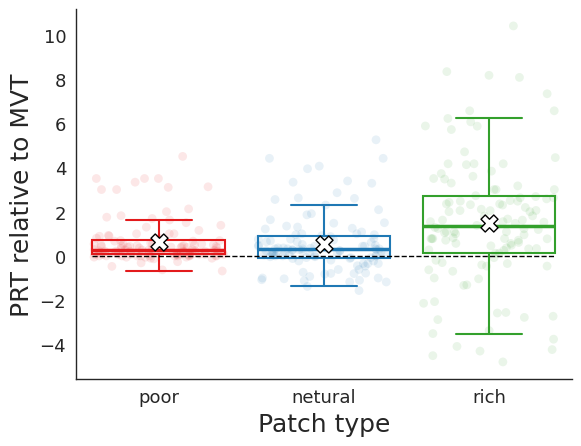

In [9]:
def overharveting_by_galaxy(df, col='prt_rel_mvt', save=False):
    df = df.copy()
    df = df[['sub_num', 'galaxy','fileID', col]].reset_index(drop=True)
    df = df.groupby(['sub_num', 'galaxy','fileID']).mean().reset_index() # get mean values for each subject, plot the median among all subjects

    galaxies = [0,1,2]  # x label positions
    # colors = ['r', 'b', 'g']
    pal = sns.color_palette("Paired")
    colors = [pal[5],pal[1],pal[3]]
    fig, ax = plt.subplots()

    box_wid = 0.8

    # noticed that the first parameter is a 2D array, with each subset array containing the data for one galaxy type, 3 x # of subjects
    # showfilers = False -> not showing outlier
    boxplot_dict = ax.boxplot([df[df['galaxy']==x][col] for x in range(len(galaxies))], positions = galaxies, patch_artist = True, widths = box_wid, showfliers=False)
    
    # for each box, set color and linewidth
    for b, c in zip(boxplot_dict['boxes'], colors):
        b.set_edgecolor(c) 
        b.set_facecolor('None')
        b.set_linewidth(1.5)

    
    # NOTE: there is one box, one median, TWO whiskers and TWO caps for each column of the box plot!
    # so there are 6 items when we go through whiskers/caps in this case, 2 for each
    for component in ['whiskers', 'caps']:
        i = 0
        for item in boxplot_dict[component]:
            item.set_linewidth(1.5)
            item.set_color(colors[i//2])
            i+=1

    # set median lines to be thicker for visibility
    for b, c in zip(boxplot_dict['medians'], colors):
        b.set_color(c)
        b.set_linewidth(2.5)

    # scatter plot for individual data points and group means
    for i in range(len(galaxies)):
        sub_df = df[df['galaxy']==galaxies[i]]
        ax.scatter([galaxies[i]]*sub_df.shape[0]+np.random.uniform(0-box_wid/2, 0+box_wid/2, size=sub_df.shape[0]), sub_df[col], facecolor=colors[i], edgecolor='None', alpha=0.1, s=40)
        ax.scatter(galaxies[i], np.mean(df[df['galaxy']==galaxies[i]][col]), marker='X', edgecolor='k', facecolor='white', s=150, zorder=10, linewidths=1)

    # Remove the top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Set the line width of the x and y axes
    ax.spines['bottom'].set_linewidth(1) # x-axis
    ax.spines['left'].set_linewidth(1) # y-axis

    ax.tick_params(axis='both', which='major', width=1) # set tick line width

    plt.xticks(galaxies, ['poor', 'netural', 'rich'])
    plt.xlabel('Patch type')
    
    if col=='prt':
        y_lab = 'PRT'
    elif col=='prt_rel_mvt':
        y_lab = 'PRT relative to MVT'
        plt.plot([0-box_wid/2,2+box_wid/2],[0,0],'k--', linewidth=1)
    plt.ylabel(y_lab)

    if save:
        plt.savefig(save+'/sns_'+col+'.svg', bbox_inches='tight')

    return df



NH_QUIC_prt_rel_om_mean_df = overharveting_by_galaxy(all_data[all_data.expGroup=='NH_QUIC'], 'prt_rel_mvt')

In [10]:
NH_QUIC_prt_rel_om_mean_df

,sub_num,galaxy,fileID,prt_rel_mvt
0,204,0,cf408j6o,0.285714
1,204,1,cf408j6o,-1.000000
2,204,2,cf408j6o,-2.142857
3,205,0,ozckhtpn,0.071429
4,205,1,ozckhtpn,0.346154
...,...,...,...,...
343,400,1,udatcanb,0.320000
344,400,2,udatcanb,0.782609
345,401,0,v4lf8fmg,0.800000
346,401,1,v4lf8fmg,0.000000


In [2]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# ============================================================
# CONFIG
# ============================================================
X_VAR = "FA_factor_1"   # ELU
OUTCOMES = [
    "prt_avg_rel_mvt_poor",
    "prt_avg_rel_mvt_mid",
    "prt_avg_rel_mvt_rich"
]

MED_SINGLE = "gamma_coef"
MED_PARALLEL = ["gamma_coef", "gamma_base"]

N_BOOT = 5000
SEED = 123

# Optional covariates: add Age/Gender/etc if desired
COVARS = []   # e.g. ["Age"]

# ============================================================
# HELPERS
# ============================================================
rng = np.random.default_rng(SEED)

def clean_for_vars(df, cols):
    tmp = df[cols].copy()
    return tmp.replace([np.inf, -np.inf], np.nan).dropna()

def fit_ols(formula, data):
    return smf.ols(formula, data=data).fit()

def bootstrap_sample(df):
    idx = rng.integers(0, len(df), len(df))
    return df.iloc[idx].reset_index(drop=True)

def pct_ci(arr, alpha=0.05):
    lo = np.percentile(arr, 100 * (alpha / 2))
    hi = np.percentile(arr, 100 * (1 - alpha / 2))
    return lo, hi

# ============================================================
# SINGLE MEDIATOR: X -> M -> Y
# ============================================================
def single_mediation(df, x, m, y, covars=None, n_boot=5000):
    if covars is None:
        covars = []

    cols = [x, m, y] + covars
    dat = clean_for_vars(df, cols)

    # a-path
    rhs_m = " + ".join([x] + covars)
    mod_a = fit_ols(f"{m} ~ {rhs_m}", dat)

    # b and c'-paths
    rhs_y = " + ".join([x, m] + covars)
    mod_b = fit_ols(f"{y} ~ {rhs_y}", dat)

    # total effect c
    rhs_total = " + ".join([x] + covars)
    mod_total = fit_ols(f"{y} ~ {rhs_total}", dat)

    a = mod_a.params[x]
    b = mod_b.params[m]
    c_prime = mod_b.params[x]
    c_total = mod_total.params[x]
    indirect = a * b

    # bootstrap indirect effect
    boot_indirect = []
    for _ in range(n_boot):
        bs = bootstrap_sample(dat)
        try:
            a_bs = fit_ols(f"{m} ~ {rhs_m}", bs).params[x]
            b_bs = fit_ols(f"{y} ~ {rhs_y}", bs).params[m]
            boot_indirect.append(a_bs * b_bs)
        except Exception:
            continue

    boot_indirect = np.array(boot_indirect)
    ci_lo, ci_hi = pct_ci(boot_indirect)

    prop_med = np.nan
    if np.isfinite(c_total) and c_total != 0:
        prop_med = indirect / c_total

    out = {
        "N": len(dat),
        "a_path": a,
        "b_path": b,
        "c_total": c_total,
        "c_prime": c_prime,
        "indirect": indirect,
        "indirect_ci_lo": ci_lo,
        "indirect_ci_hi": ci_hi,
        "prop_mediated": prop_med,
        "a_p": mod_a.pvalues.get(x, np.nan),
        "b_p": mod_b.pvalues.get(m, np.nan),
        "c_total_p": mod_total.pvalues.get(x, np.nan),
        "c_prime_p": mod_b.pvalues.get(x, np.nan),
    }
    return out

# ============================================================
# PARALLEL MEDIATORS: X -> M1, X -> M2, and Y ~ X + M1 + M2
# ============================================================
def parallel_mediation(df, x, mediators, y, covars=None, n_boot=5000):
    if covars is None:
        covars = []

    m1, m2 = mediators
    cols = [x, m1, m2, y] + covars
    dat = clean_for_vars(df, cols)

    # a-paths
    rhs_m = " + ".join([x] + covars)
    mod_a1 = fit_ols(f"{m1} ~ {rhs_m}", dat)
    mod_a2 = fit_ols(f"{m2} ~ {rhs_m}", dat)

    # outcome model with both mediators simultaneously
    rhs_y = " + ".join([x, m1, m2] + covars)
    mod_y = fit_ols(f"{y} ~ {rhs_y}", dat)

    # total effect
    rhs_total = " + ".join([x] + covars)
    mod_total = fit_ols(f"{y} ~ {rhs_total}", dat)

    a1 = mod_a1.params[x]
    a2 = mod_a2.params[x]
    b1 = mod_y.params[m1]
    b2 = mod_y.params[m2]

    ind1 = a1 * b1
    ind2 = a2 * b2
    ind_total = ind1 + ind2

    c_prime = mod_y.params[x]
    c_total = mod_total.params[x]

    # bootstrap
    boot_ind1 = []
    boot_ind2 = []
    boot_ind_total = []

    for _ in range(n_boot):
        bs = bootstrap_sample(dat)
        try:
            a1_bs = fit_ols(f"{m1} ~ {rhs_m}", bs).params[x]
            a2_bs = fit_ols(f"{m2} ~ {rhs_m}", bs).params[x]
            mod_y_bs = fit_ols(f"{y} ~ {rhs_y}", bs)

            b1_bs = mod_y_bs.params[m1]
            b2_bs = mod_y_bs.params[m2]

            i1 = a1_bs * b1_bs
            i2 = a2_bs * b2_bs

            boot_ind1.append(i1)
            boot_ind2.append(i2)
            boot_ind_total.append(i1 + i2)
        except Exception:
            continue

    boot_ind1 = np.array(boot_ind1)
    boot_ind2 = np.array(boot_ind2)
    boot_ind_total = np.array(boot_ind_total)

    ci1 = pct_ci(boot_ind1)
    ci2 = pct_ci(boot_ind2)
    ciT = pct_ci(boot_ind_total)

    prop_med = np.nan
    if np.isfinite(c_total) and c_total != 0:
        prop_med = ind_total / c_total

    out = {
        "N": len(dat),
        "a1_path": a1,
        "a2_path": a2,
        "b1_path": b1,
        "b2_path": b2,
        "indirect_1": ind1,
        "indirect_1_ci_lo": ci1[0],
        "indirect_1_ci_hi": ci1[1],
        "indirect_2": ind2,
        "indirect_2_ci_lo": ci2[0],
        "indirect_2_ci_hi": ci2[1],
        "indirect_total": ind_total,
        "indirect_total_ci_lo": ciT[0],
        "indirect_total_ci_hi": ciT[1],
        "c_total": c_total,
        "c_prime": c_prime,
        "prop_mediated": prop_med,
        "a1_p": mod_a1.pvalues.get(x, np.nan),
        "a2_p": mod_a2.pvalues.get(x, np.nan),
        "b1_p": mod_y.pvalues.get(m1, np.nan),
        "b2_p": mod_y.pvalues.get(m2, np.nan),
        "c_total_p": mod_total.pvalues.get(x, np.nan),
        "c_prime_p": mod_y.pvalues.get(x, np.nan),
    }
    return out

# ============================================================
# RUN ALL TESTS
# ============================================================
single_rows = []
parallel_rows = []

print("\n================ SINGLE MEDIATOR: ELU → gamma_coef → overharvesting ================\n")

for y in OUTCOMES:
    res = single_mediation(df, x=X_VAR, m=MED_SINGLE, y=y, covars=COVARS, n_boot=N_BOOT)
    single_rows.append({"outcome": y, **res})

    print(f"Outcome: {y}")
    print(f"  N = {res['N']}")
    print(f"  a path ({X_VAR} → {MED_SINGLE}) = {res['a_path']:.4f}, p = {res['a_p']:.4g}")
    print(f"  b path ({MED_SINGLE} → {y} | X) = {res['b_path']:.4f}, p = {res['b_p']:.4g}")
    print(f"  Total effect c ({X_VAR} → {y}) = {res['c_total']:.4f}, p = {res['c_total_p']:.4g}")
    print(f"  Direct effect c' ({X_VAR} → {y} | mediator) = {res['c_prime']:.4f}, p = {res['c_prime_p']:.4g}")
    print(f"  Indirect effect ab = {res['indirect']:.4f}")
    print(f"  95% bootstrap CI = [{res['indirect_ci_lo']:.4f}, {res['indirect_ci_hi']:.4f}]")
    print(f"  Proportion mediated = {res['prop_mediated']:.4f}")
    print("-" * 80)

print("\n================ PARALLEL MEDIATORS: ELU → [gamma_coef, gamma_base] → overharvesting ================\n")

for y in OUTCOMES:
    res = parallel_mediation(df, x=X_VAR, mediators=MED_PARALLEL, y=y, covars=COVARS, n_boot=N_BOOT)
    parallel_rows.append({"outcome": y, **res})

    print(f"Outcome: {y}")
    print(f"  N = {res['N']}")
    print(f"  a1 path ({X_VAR} → gamma_coef) = {res['a1_path']:.4f}, p = {res['a1_p']:.4g}")
    print(f"  a2 path ({X_VAR} → gamma_base) = {res['a2_path']:.4f}, p = {res['a2_p']:.4g}")
    print(f"  b1 path (gamma_coef → {y} | X, gamma_base) = {res['b1_path']:.4f}, p = {res['b1_p']:.4g}")
    print(f"  b2 path (gamma_base → {y} | X, gamma_coef) = {res['b2_path']:.4f}, p = {res['b2_p']:.4g}")
    print(f"  Total effect c ({X_VAR} → {y}) = {res['c_total']:.4f}, p = {res['c_total_p']:.4g}")
    print(f"  Direct effect c' ({X_VAR} → {y} | both mediators) = {res['c_prime']:.4f}, p = {res['c_prime_p']:.4g}")
    print(f"  Indirect via gamma_coef = {res['indirect_1']:.4f}")
    print(f"  95% bootstrap CI = [{res['indirect_1_ci_lo']:.4f}, {res['indirect_1_ci_hi']:.4f}]")
    print(f"  Indirect via gamma_base = {res['indirect_2']:.4f}")
    print(f"  95% bootstrap CI = [{res['indirect_2_ci_lo']:.4f}, {res['indirect_2_ci_hi']:.4f}]")
    print(f"  Total indirect = {res['indirect_total']:.4f}")
    print(f"  95% bootstrap CI = [{res['indirect_total_ci_lo']:.4f}, {res['indirect_total_ci_hi']:.4f}]")
    print(f"  Proportion mediated = {res['prop_mediated']:.4f}")
    print("-" * 80)

# ============================================================
# OPTIONAL: save results
# ============================================================
single_df = pd.DataFrame(single_rows)
parallel_df = pd.DataFrame(parallel_rows)

print("\n=== SINGLE-MEDIATOR SUMMARY TABLE ===")
print(single_df.round(4))

print("\n=== PARALLEL-MEDIATOR SUMMARY TABLE ===")
print(parallel_df.round(4))

# Optional save
# single_df.to_csv("mediation_single_gamma_coef.csv", index=False)
# parallel_df.to_csv("mediation_parallel_gamma_coef_gamma_base.csv", index=False)


================ SINGLE MEDIATOR: ELU → gamma_coef → overharvesting ================

Outcome: prt_avg_rel_mvt_poor
  N = 297
  a path (FA_factor_1 → gamma_coef) = 0.0402, p = 0.0007878
  b path (gamma_coef → prt_avg_rel_mvt_poor | X) = 0.5366, p = 5.812e-13
  Total effect c (FA_factor_1 → prt_avg_rel_mvt_poor) = 0.0520, p = 0.001108
  Direct effect c' (FA_factor_1 → prt_avg_rel_mvt_poor | mediator) = 0.0304, p = 0.03999
  Indirect effect ab = 0.0216
  95% bootstrap CI = [0.0084, 0.0362]
  Proportion mediated = 0.4146
--------------------------------------------------------------------------------
Outcome: prt_avg_rel_mvt_mid
  N = 297
  a path (FA_factor_1 → gamma_coef) = 0.0402, p = 0.0007878
  b path (gamma_coef → prt_avg_rel_mvt_mid | X) = 0.6949, p = 2.152e-11
  Total effect c (FA_factor_1 → prt_avg_rel_mvt_mid) = 0.0492, p = 0.02521
  Direct effect c' (FA_factor_1 → prt_avg_rel_mvt_mid | mediator) = 0.0213, p = 0.3045
  Indirect effect ab = 0.0279
  95% bootstrap CI = [0.0100, 0

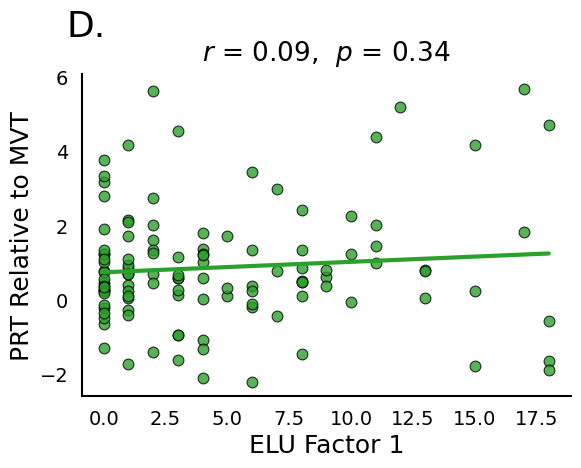


🎉 Saved ELU vs PRT figure to:
C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new\ELU_vs_PRT.png

✅ Regression dataframe for ['prt_rel_mvt_avg', 'FA_factor_1']
Rows retained: 116

Total effect: ELU Factor 1 -> PRT Relative to MVT
                            OLS Regression Results                            
Dep. Variable:        prt_rel_mvt_avg   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.9024
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.344
Time:                        09:27:26   Log-Likelihood:                -218.04
No. Observations:                 116   AIC:                             440.1
Df Residuals:                     114   BIC:                             445.6
Df Model:                           1                        

In [19]:


# ============================================================
# AFTER plot D is created:
# Additional plot + mediation + predictive regression
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import pearsonr
from sklearn.utils import resample
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ============================================================
# 1. EXTRA PLOT: ELU Factor 1 vs PRT Relative to MVT
# ============================================================

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor("white")

plot_panel(
    ax, merged,
    x="FA_factor_1",
    y="prt_rel_mvt_avg",
    xlabel="ELU Factor 1",
    ylabel="PRT Relative to MVT",
    color="#2ca02c"
)

add_label(ax, "D.")
plt.tight_layout()

save_path_extra = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new\ELU_vs_PRT.png"
plt.savefig(save_path_extra, dpi=400, bbox_inches="tight", facecolor="white")
plt.show()

print(f"\n🎉 Saved ELU vs PRT figure to:\n{save_path_extra}")


# ============================================================
# 2. HELPER FUNCTIONS FOR REGRESSION
# ============================================================

def prepare_numeric_regression_df(df, columns):
    """
    Keep requested columns, coerce to numeric, drop missing/infinite rows.
    """
    missing_cols = [c for c in columns if c not in df.columns]
    if missing_cols:
        print(f"\n⚠️ Missing columns: {missing_cols}")
        return None

    data = df[columns].copy()

    for c in columns:
        data[c] = pd.to_numeric(data[c], errors="coerce")

    data = data.replace([np.inf, -np.inf], np.nan).dropna()

    if data.shape[0] == 0:
        print(f"\n⚠️ No rows left after dropna() for columns: {columns}")
        return None

    print(f"\n✅ Regression dataframe for {columns}")
    print(f"Rows retained: {len(data)}")

    return data


def run_regression(df, y, X_vars, model_name="Regression"):
    """
    Safe OLS wrapper.
    """
    cols = [y] + X_vars
    data = prepare_numeric_regression_df(df, cols)

    if data is None or len(data) < 5:
        print(f"\n⚠️ Skipping {model_name}: insufficient usable rows.")
        return None, None

    X = sm.add_constant(data[X_vars], has_constant="add")
    y_vals = data[y]

    model = sm.OLS(y_vals, X).fit()

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)
    print(model.summary())

    return model, data


# ============================================================
# 3. MEDIATION-STYLE REGRESSIONS
#    ELU Factor 1 -> gamma_coef -> PRT Relative to MVT
# ============================================================

# total effect: ELU -> PRT
model_total, data_total = run_regression(
    merged,
    y="prt_rel_mvt_avg",
    X_vars=["FA_factor_1"],
    model_name="Total effect: ELU Factor 1 -> PRT Relative to MVT"
)

# a path: ELU -> gamma_coef
model_a, data_a = run_regression(
    merged,
    y="gamma_coef",
    X_vars=["FA_factor_1"],
    model_name="a path: ELU Factor 1 -> gamma_coef"
)

# b path / direct effect: gamma_coef + ELU -> PRT
model_b, data_b = run_regression(
    merged,
    y="prt_rel_mvt_avg",
    X_vars=["gamma_coef", "FA_factor_1"],
    model_name="b path + direct effect: gamma_coef and ELU Factor 1 -> PRT Relative to MVT"
)


# ============================================================
# 4. BOOTSTRAP INDIRECT EFFECT
# ============================================================

def bootstrap_mediation(df, x="FA_factor_1", m="gamma_coef", y="prt_rel_mvt_avg", n_boot=5000, seed=123):
    np.random.seed(seed)

    data = prepare_numeric_regression_df(df, [x, m, y])
    if data is None or len(data) < 20:
        print("\n⚠️ Not enough usable rows for bootstrap mediation.")
        return None

    indirect_effects = []

    for _ in range(n_boot):
        sample = resample(data, replace=True, n_samples=len(data))

        # a path
        Xa = sm.add_constant(sample[[x]], has_constant="add")
        model_a_boot = sm.OLS(sample[m], Xa).fit()
        a = model_a_boot.params[x]

        # b path
        Xb = sm.add_constant(sample[[m, x]], has_constant="add")
        model_b_boot = sm.OLS(sample[y], Xb).fit()
        b = model_b_boot.params[m]

        indirect_effects.append(a * b)

    indirect_effects = np.array(indirect_effects)

    mean_indirect = indirect_effects.mean()
    ci_low = np.percentile(indirect_effects, 2.5)
    ci_high = np.percentile(indirect_effects, 97.5)

    print("\n" + "=" * 70)
    print("Bootstrap mediation")
    print("=" * 70)
    print(f"Indirect effect (a*b): {mean_indirect:.5f}")
    print(f"95% bootstrap CI: [{ci_low:.5f}, {ci_high:.5f}]")

    return {
        "mean_indirect": mean_indirect,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "samples": indirect_effects
    }

boot_result = bootstrap_mediation(merged)


# ============================================================
# 5. PREDICTIVE REGRESSION FOR PRT Relative to MVT
#    WITHOUT beta
# ============================================================

# Candidate predictors to consider
candidate_predictors = ["gamma_coef", "gamma_base", "FA_factor_1", "MST_Score"]

print("\nAvailable candidate predictors:")
for c in candidate_predictors:
    print(f"{c}: {'YES' if c in merged.columns else 'NO'}")

# Keep only columns that actually exist
available_predictors = [c for c in candidate_predictors if c in merged.columns]

print(f"\nUsing available predictors: {available_predictors}")

# Full predictive model with whatever is available
if len(available_predictors) > 0:
    model_full, data_full = run_regression(
        merged,
        y="prt_rel_mvt_avg",
        X_vars=available_predictors,
        model_name="Predictive model: PRT Relative to MVT from available predictors"
    )
else:
    model_full, data_full = None, None
    print("\n⚠️ No predictors available for full model.")


# ============================================================
# 6. VIF / COLLINEARITY CHECK
# ============================================================

def compute_vif(df, vars_list):
    data = prepare_numeric_regression_df(df, vars_list)
    if data is None or len(data) < 5:
        print("\n⚠️ Not enough usable rows for VIF.")
        return None

    X = sm.add_constant(data, has_constant="add")

    vif_df = pd.DataFrame({
        "variable": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    })

    print("\n" + "=" * 70)
    print("Variance Inflation Factors")
    print("=" * 70)
    print(vif_df)

    return vif_df

if len(available_predictors) >= 2:
    vif_df = compute_vif(merged, available_predictors)
else:
    vif_df = None
    print("\n⚠️ Need at least 2 predictors for a meaningful VIF check.")


# ============================================================
# 7. THEORY-DRIVEN REDUCED MODELS
# ============================================================

# Model 1: gamma_base only
if "gamma_base" in merged.columns:
    model_gbase, data_gbase = run_regression(
        merged,
        y="prt_rel_mvt_avg",
        X_vars=["gamma_base"],
        model_name="Model 1: PRT Relative to MVT ~ gamma_base"
    )
else:
    model_gbase = None

# Model 2: gamma_base + gamma_coef
if all(c in merged.columns for c in ["gamma_base", "gamma_coef"]):
    model_gboth, data_gboth = run_regression(
        merged,
        y="prt_rel_mvt_avg",
        X_vars=["gamma_base", "gamma_coef"],
        model_name="Model 2: PRT Relative to MVT ~ gamma_base + gamma_coef"
    )
else:
    model_gboth = None

# Model 3: gamma_base + gamma_coef + ELU
if all(c in merged.columns for c in ["gamma_base", "gamma_coef", "FA_factor_1"]):
    model_theory, data_theory = run_regression(
        merged,
        y="prt_rel_mvt_avg",
        X_vars=["gamma_base", "gamma_coef", "FA_factor_1"],
        model_name="Model 3: PRT Relative to MVT ~ gamma_base + gamma_coef + ELU Factor 1"
    )
else:
    model_theory = None

# Optional model with MST only if enough data remain
if all(c in merged.columns for c in ["gamma_base", "gamma_coef", "FA_factor_1", "MST_Score"]):
    model_theory_mst, data_theory_mst = run_regression(
        merged,
        y="prt_rel_mvt_avg",
        X_vars=["gamma_base", "gamma_coef", "FA_factor_1", "MST_Score"],
        model_name="Model 4: PRT Relative to MVT ~ gamma_base + gamma_coef + ELU Factor 1 + MST"
    )
else:
    model_theory_mst = None


# ============================================================
# 8. MODEL COMPARISON
# ============================================================

def compare_models(*models):
    valid_models = [m for m in models if m is not None]
    if len(valid_models) < 2:
        print("\n⚠️ Need at least 2 valid models to compare.")
        return

    print("\n" + "=" * 70)
    print("Model comparison (AIC / BIC / Adj. R^2)")
    print("=" * 70)

    rows = []
    for i, m in enumerate(valid_models, 1):
        rows.append({
            "Model": f"Model {i}",
            "AIC": m.aic,
            "BIC": m.bic,
            "Adj_R2": m.rsquared_adj
        })

    comp = pd.DataFrame(rows)
    print(comp)

compare_models(model_gbase, model_gboth, model_theory, model_theory_mst)


# ============================================================
# 9. OPTIONAL: QUICK CORRELATION PRINT FOR ELU vs PRT
# ============================================================

corr_data = prepare_numeric_regression_df(merged, ["FA_factor_1", "prt_rel_mvt_avg"])
if corr_data is not None and len(corr_data) >= 3:
    r, p = pearsonr(corr_data["FA_factor_1"], corr_data["prt_rel_mvt_avg"])
    print("\n" + "=" * 70)
    print("Correlation: ELU Factor 1 vs PRT Relative to MVT")
    print("=" * 70)
    print(f"r = {r:.4f}, p = {p:.4g}, n = {len(corr_data)}")

### Actual QUIC Questionnaire and Factor vs Parameters
1. I had a set morning routine on school days (i.e., I usually did the same thing each day to get ready).	
2. My parents were often late to pick me up (e.g. from school, aftercare or sports).
3. My parents kept track of what I ate (e.g., made sure that I didnâ€™t skip meals or tried to make sure I ate healthy food).
4. My family ate a meal together most days.	
5. My parents tried to make sure I got a good night's sleep (e.g., I had a regular bed time, my parents checked to make sure I went to sleep).	
6. I had a bedtime routine (e.g., my parents tucked me in, my parents read me a book, I took a bath).	
7. In my after school or free time hours at least one of my parents knew what I was doing.	
8. I usually knew when my parents were going to be home.	
9. At least one of my parents regularly checked that I did my homework.	
10. At least one of my parents regularly kept track of my school progress.	
11. At least one of my parents had punishments that were unpredictable. 	
12. I often wondered whether or not one of my parents would come home at the end of the day.	
3. There were often people coming and going in my house that I did not expect to be there.	
14. At least one parent made time each day to see how I was doing.	
15. My family planned activities to do together	
16. At least one of my parents would plan something for the family, but then not follow through with the plan.	
17. My family had holiday traditions that we did every year (e.g.,cooking a special food at a particular time of year/decorate the house the same way).	
18. There was a long period of time when I didnâ€™t see one of my parents (e.g. military deployment, jail time, custody arrangements).	
19. I experienced changes in my custody arrangement. 	
20. I moved frequently.	
21. At least one of my parents changed jobs frequently.	
22. There were times when one of my parents was unemployed and couldnâ€™t find a job even though he/she wanted one. 	
23. There was a period of time when I often worried that I was not going to have enough food to eat.	
24. There was a period of time when I often worried that my family would not have enough money to pay for necessities like clothing or bills.	
25. There was a period of time when I did not feel safe in my home. 	
26. I changed schools frequently.	
27. I changed schools mid-year. 	
28. My parents had a stable relationship with each other.	
29. My parents got divorced.	
30. At least one of my parents had many romantic partners. 	
31. At least one of my parents was disorganized.	
32. At least one of my parents was unpredictable.	
33. For at least one of my parents, when they were upset I did not know how they would act. 	
34. One of my parents could go from calm to furious in an instant.	
35. One of my parents could go from calm to stressed or nervous in an instant.	
36. I lived in a clean house.	
37. I lived in a cluttered house (e.g., piles of stuff everywhere).	
38. In my house things I needed were often misplaced so that I could not find them.




factorLists{1} = sort([12,23,13,21,2,19,25,20,16,24,22,37,38,30,18,26,27,11,28]);
factorLists{2} = sort([5,6,9,14,3,15,7,4,8,10,1,28]);
factorLists{3} = sort([34,33,32,35,11,31]);
factorLists{4} = sort([26,27,29,20]);
factorLists{5} = sort([10,17]);
factorLists{6} = sort([37,38,36]);



🔍 QUIC FACTOR QUESTION SETS

FACTOR 1: 19 items
  Q2: My parents were often late to pick me up.
  Q11: At least one of my parents had unpredictable punishments.
  Q12: I often wondered whether a parent would come home at the end of the day.
  Q13: There were often unexpected people in my house.
  Q16: A parent planned something for the family but did not follow through.
  Q18: There was a long period when I didn’t see one parent.
  Q19: I experienced changes in custody arrangements.
  Q20: I moved frequently.
  Q21: A parent changed jobs frequently.
  Q22: A parent was unemployed for long periods.
  Q23: I often worried about having enough food.
  Q24: I often worried we didn’t have enough money for necessities.
  Q25: I did not feel safe in my home.
  Q26: I changed schools frequently.
  Q27: I changed schools mid-year.
  Q28: My parents had a stable relationship.
  Q30: A parent had many romantic partners.
  Q37: Things I needed were often misplaced.
  Q38: Items in the house were o

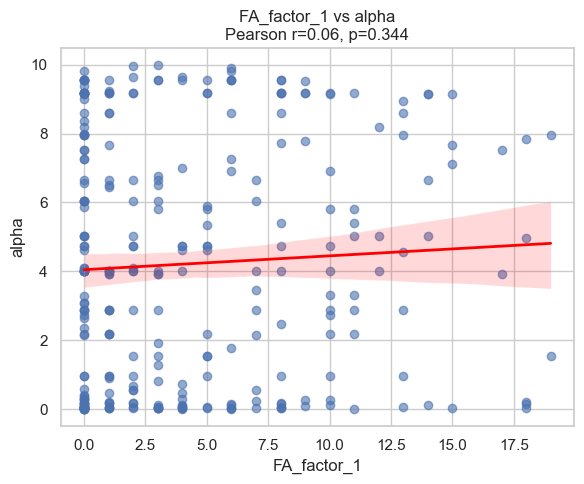

Saved: FA_factor_1_vs_alpha.png


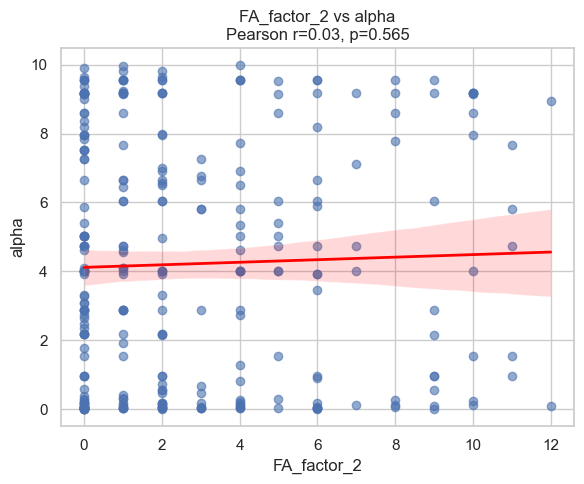

Saved: FA_factor_2_vs_alpha.png


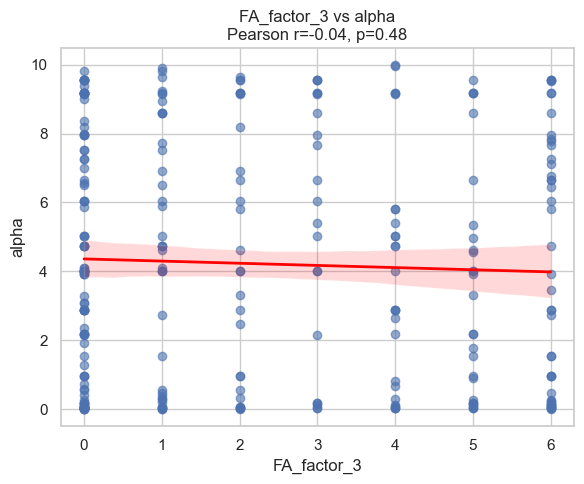

Saved: FA_factor_3_vs_alpha.png


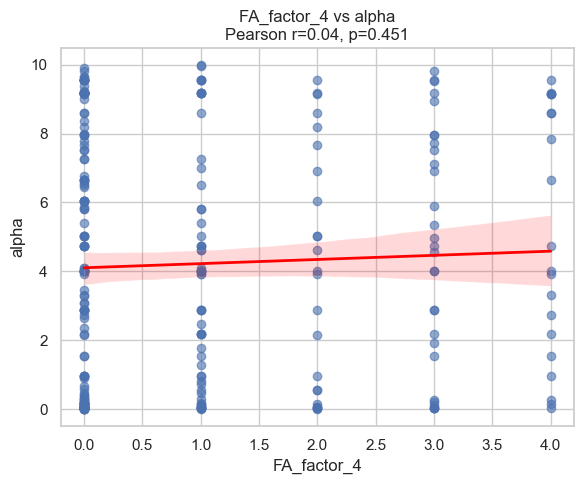

Saved: FA_factor_4_vs_alpha.png


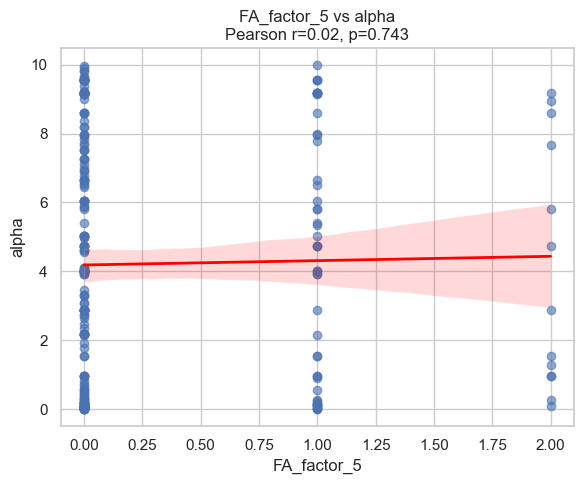

Saved: FA_factor_5_vs_alpha.png


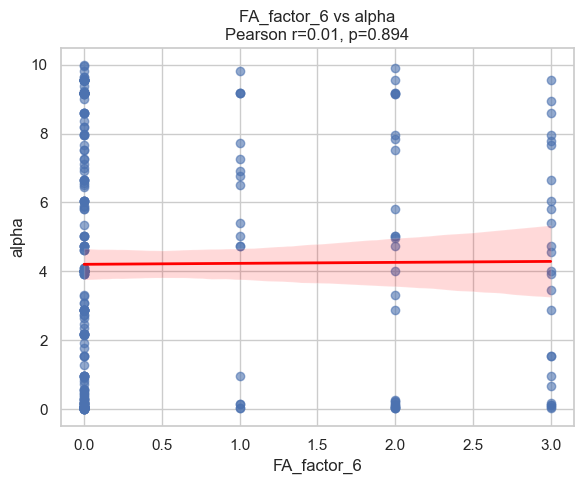

Saved: FA_factor_6_vs_alpha.png


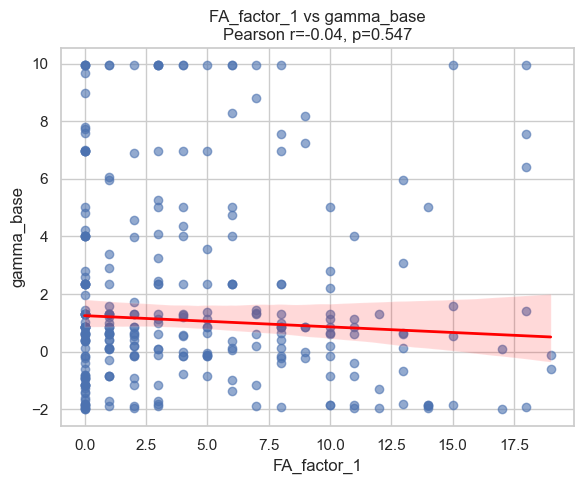

Saved: FA_factor_1_vs_gamma_base.png


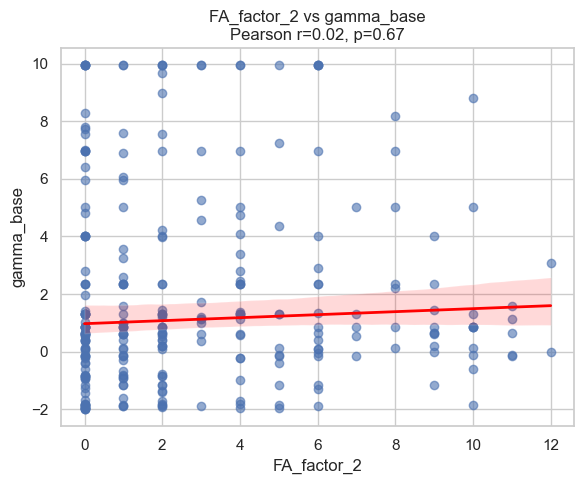

Saved: FA_factor_2_vs_gamma_base.png


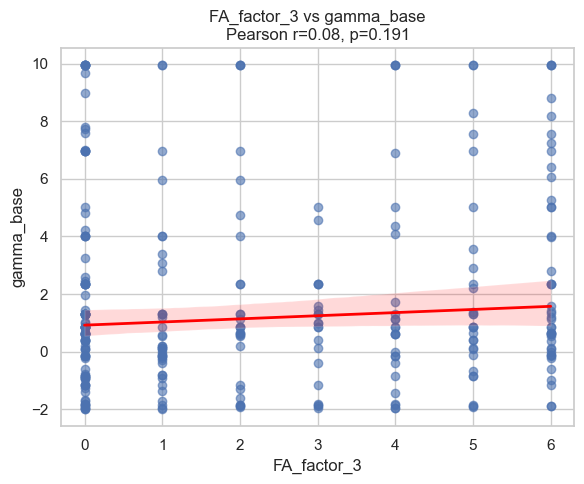

Saved: FA_factor_3_vs_gamma_base.png


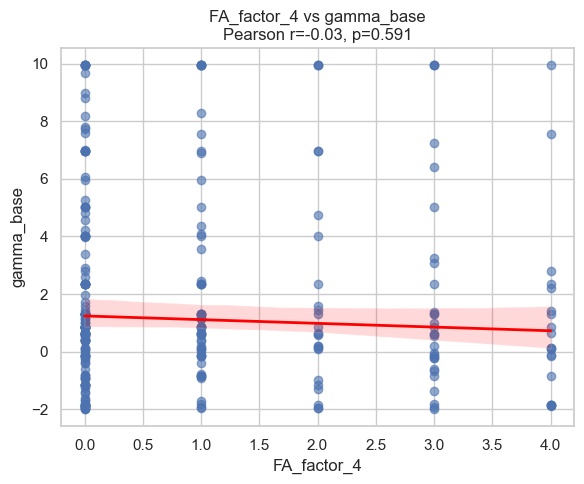

Saved: FA_factor_4_vs_gamma_base.png


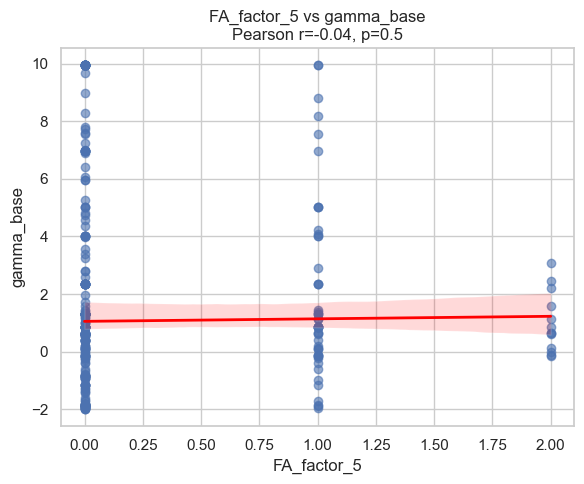

Saved: FA_factor_5_vs_gamma_base.png


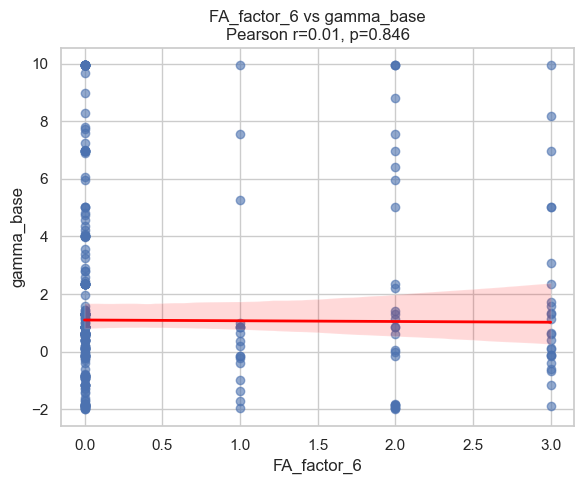

Saved: FA_factor_6_vs_gamma_base.png


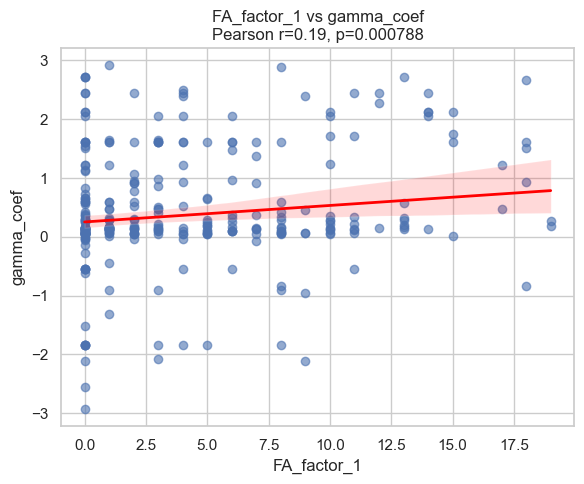

Saved: FA_factor_1_vs_gamma_coef.png


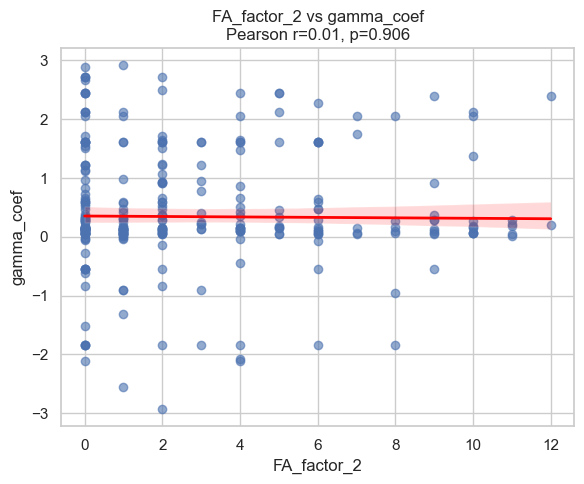

Saved: FA_factor_2_vs_gamma_coef.png


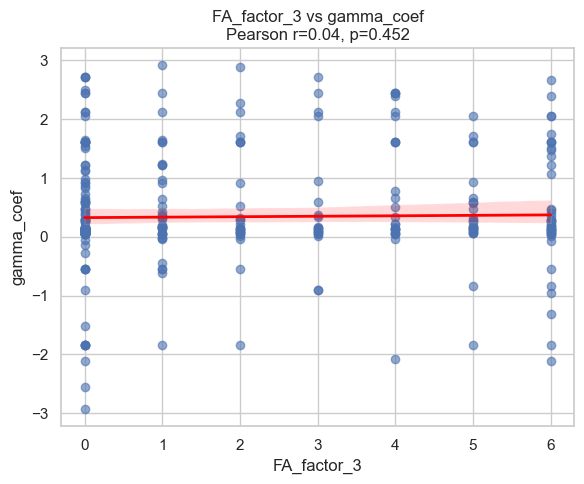

Saved: FA_factor_3_vs_gamma_coef.png


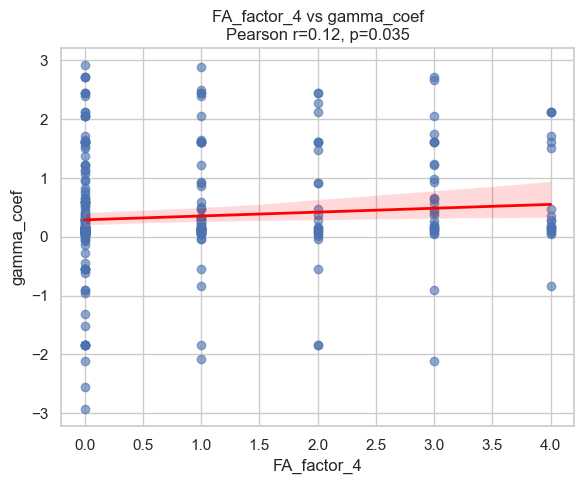

Saved: FA_factor_4_vs_gamma_coef.png


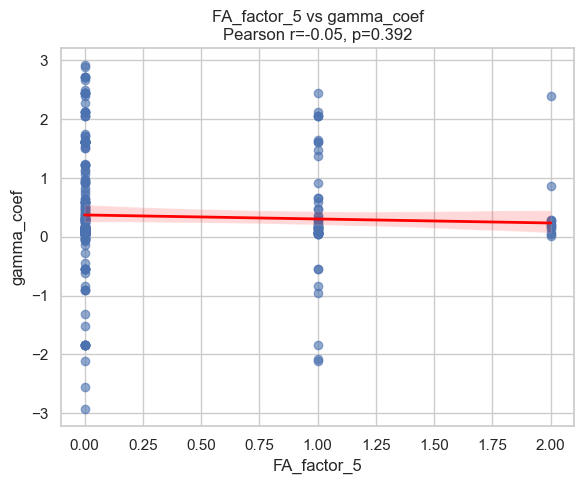

Saved: FA_factor_5_vs_gamma_coef.png


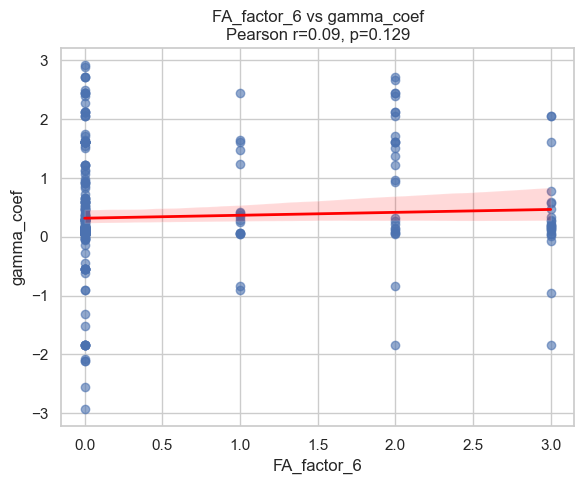

Saved: FA_factor_6_vs_gamma_coef.png

🎉 DONE! All plots saved.


In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import os

# ============================================================
# 0. Predefined QUIC questionnaire text (indexed 1–38)
# ============================================================
quic_questions = {
    1: "I had a set morning routine on school days.",
    2: "My parents were often late to pick me up.",
    3: "My parents kept track of what I ate.",
    4: "My family ate a meal together most days.",
    5: "My parents tried to make sure I got a good night's sleep.",
    6: "I had a bedtime routine.",
    7: "At least one of my parents knew what I was doing after school.",
    8: "I usually knew when my parents would be home.",
    9: "At least one of my parents checked I did my homework.",
    10: "At least one of my parents kept track of my school progress.",
    11: "At least one of my parents had unpredictable punishments.",
    12: "I often wondered whether a parent would come home at the end of the day.",
    13: "There were often unexpected people in my house.",
    14: "At least one parent checked on me each day.",
    15: "My family planned activities together.",
    16: "A parent planned something for the family but did not follow through.",
    17: "My family had holiday traditions every year.",
    18: "There was a long period when I didn’t see one parent.",
    19: "I experienced changes in custody arrangements.",
    20: "I moved frequently.",
    21: "A parent changed jobs frequently.",
    22: "A parent was unemployed for long periods.",
    23: "I often worried about having enough food.",
    24: "I often worried we didn’t have enough money for necessities.",
    25: "I did not feel safe in my home.",
    26: "I changed schools frequently.",
    27: "I changed schools mid-year.",
    28: "My parents had a stable relationship.",
    29: "My parents got divorced.",
    30: "A parent had many romantic partners.",
    31: "A parent was disorganized.",
    32: "A parent was unpredictable.",
    33: "A parent could go from calm to furious instantly.",
    34: "A parent could go from calm to stressed instantly.",
    35: "I lived in a clean house.",
    36: "I lived in a cluttered house.",
    37: "Things I needed were often misplaced.",
    38: "Items in the house were often cluttered/misplaced."
}

# ============================================================
# 1. Predefined Factor Lists (advisor/Yifei method)
# ============================================================
factor_lists = {
    1: sorted([12,23,13,21,2,19,25,20,16,24,22,37,38,30,18,26,27,11,28]),
    2: sorted([5,6,9,14,3,15,7,4,8,10,1,28]),
    3: sorted([34,33,32,35,11,31]),
    4: sorted([26,27,29,20]),
    5: sorted([10,17]),
    6: sorted([37,38,36])
}

# ============================================================
# 2. Print the exact questions belonging to each factor
# ============================================================
print("\n==========================")
print("🔍 QUIC FACTOR QUESTION SETS")
print("==========================\n")

for f_idx, items in factor_lists.items():
    print(f"FACTOR {f_idx}: {len(items)} items")
    for qnum in items:
        print(f"  Q{qnum}: {quic_questions[qnum]}")
    print()

# ============================================================
# 3. Compute factor scores by summing item responses
# ============================================================
for f_idx, items in factor_lists.items():
    df[f"FA_factor_{f_idx}"] = df[[f"Q{i}" for i in items]].sum(axis=1, skipna=True)

print("\n✅ Summed factor scores added to df:")
print(df[[f"FA_factor_{i}" for i in range(1, 7)]].head())

# ============================================================
# 4. Scatter plots: each FACTOR vs each model parameter
# ============================================================

save_dir = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new"
os.makedirs(save_dir, exist_ok=True)

model_params = ["alpha", "gamma_base", "gamma_coef"]
fa_factors = [f"FA_factor_{i}" for i in range(1, 7)]

def plot_corr(df, x, y):
    clean = df[[x, y]].dropna()

    if len(clean) < 3:
        print(f"Skipping {x} vs {y} (not enough data)")
        return

    r, p = pearsonr(clean[x], clean[y])

    plt.figure(figsize=(6,5))
    sns.regplot(
        x=x, y=y, data=clean,
        robust=True,
        scatter_kws={'alpha':0.6},
        line_kws={'color': 'red', 'lw': 2}
    )
    plt.title(f"{x} vs {y}\nPearson r={r:.2f}, p={p:.3g}")
    plt.tight_layout()

    fname = f"{x}_vs_{y}.png"
    plt.savefig(os.path.join(save_dir, fname), dpi=300)
    plt.show()
    plt.close()
    print("Saved:", fname)


# Generate all plots
print("\n==========================")
print("📊 Generating factor × parameter scatter plots")
print("==========================\n")

for param in model_params:
    for factor in fa_factors:
        plot_corr(df, factor, param)

print("\n🎉 DONE! All plots saved.")


## Column Mapping Code (run only once)

## Reaction Time Analysis

#### Data Preprocessing (one time)

In [ ]:
# import pandas as pd
# import numpy as np
# import ast   # To safely parse rt_list strings

# # ============================================================
# # 0. Paths
# # ============================================================
# target_path = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data\result_df\all_foraging_data_07_02_24.csv"
# massive_path = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data\semi_raw_data\all_foraging_data_massive_ae_07_02_24.csv"


# # ============================================================
# # 1. Load subject-level df
# # ============================================================
# df = pd.read_csv(target_path)
# df["fileID"] = df["fileID"].astype(str).str.strip()
# print("Loaded subject df:", df.shape)

# # ============================================================
# # 2. Load massive dataframe
# # ============================================================
# massive_df = pd.read_csv(massive_path)
# massive_df["fileID"] = massive_df["fileID"].astype(str).str.strip()
# print("Loaded massive df:", massive_df.shape)


# # ============================================================
# # 3. Parse rt_list (string → Python list)
# # ============================================================
# def parse_list(x):
#     if isinstance(x, str):
#         try:
#             return ast.literal_eval(x)
#         except:
#             return np.nan
#     return x

# massive_df["rt_list_parsed"] = massive_df["rt_list"].apply(parse_list)


# # ============================================================
# # 4. Extract first (post-leaving) and last (pre-leaving) RTs
# # ============================================================
# def get_first(rt_list):
#     if isinstance(rt_list, list) and len(rt_list) > 0:
#         return rt_list[0]
#     return np.nan

# def get_last(rt_list):
#     if isinstance(rt_list, list) and len(rt_list) > 0:
#         return rt_list[-1]
#     return np.nan

# massive_df["rt_first"] = massive_df["rt_list_parsed"].apply(get_first)
# massive_df["rt_last"]  = massive_df["rt_list_parsed"].apply(get_last)


# # ============================================================
# # 5. Compute medians per subject (fileID)
# # ============================================================
# rt_summary_df = (
#     massive_df
#     .groupby("fileID")[["rt_first", "rt_last"]]
#     .median()
#     .reset_index()
#     .rename(columns={
#         "rt_first": "median_post_leaving_rt",
#         "rt_last":  "median_pre_leaving_rt"
#     })
# )

# print("\nRT summary per subject:")
# print(rt_summary_df.head())


# # ============================================================
# # 6. Merge into subject-level df
# # ============================================================
# df = df.merge(rt_summary_df, on="fileID", how="left")


# # ============================================================
# # 7. Save updated subject file
# # ============================================================
# df.to_csv(target_path, index=False)

# print("\nSaved updated df including RT variables →")
# print(target_path)
# print("Final shape:", df.shape)


Loaded subject df: (297, 69)
Loaded massive df: (17186, 44)

RT summary per subject:
     fileID  median_post_leaving_rt  median_pre_leaving_rt
0  01yo7fr5                  184.25                  149.8
1  02z1xetw                  579.10                  506.4
2  09jvwdof                  597.10                  347.1
3  0b2172zv                  476.40                  753.0
4  0b9569cb                  258.70                  227.1

Saved updated df including RT variables →
C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data\result_df\all_foraging_data_07_02_24.csv
Final shape: (297, 71)


In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import os

# ============================================================
# 0. Load subject-level dataset
# ============================================================
path = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data\result_df\all_foraging_data_07_02_24.csv"
df = pd.read_csv(path)

# Make sure RT columns exist
assert "median_pre_leaving_rt" in df.columns
assert "median_post_leaving_rt" in df.columns

# Factor columns
fa_cols = [f"FA_factor_{i}" for i in range(1, 7)]
rt_vars = ["median_pre_leaving_rt", "median_post_leaving_rt"]

# Output directory
save_dir = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new\quic_rt_plots"
os.makedirs(save_dir, exist_ok=True)


# ============================================================
# 1. Correlation analysis
# ============================================================
print("\n================ CORRELATION ANALYSIS ================")

for rt in rt_vars:
    for fac in fa_cols:
        sub = df[[rt, fac]].dropna()

        if len(sub) < 3:
            print(f"Skipping {fac} vs {rt} (not enough data)")
            continue

        r, p = spearmanr(sub[fac], sub[rt])

        print(f"{fac} vs {rt}: r={r:.3f}, p={p:.3g}")


# ============================================================
# 2. Scatterplots with regression lines
# ============================================================
def plot_fa_vs_rt(factor, rt_metric):
    clean = df[[factor, rt_metric]].dropna()
    if len(clean) < 3:
        return
    
    r, p = spearmanr(clean[factor], clean[rt_metric])

    plt.figure(figsize=(6,5))
    sns.regplot(
        data=clean,
        x=factor, y=rt_metric,
        scatter_kws={'alpha':0.6},
        line_kws={'lw':2, 'color':'red'}
    )
    plt.title(f"{factor} vs {rt_metric}\n r={r:.2f}, p={p:.3g} Spearman")
    plt.tight_layout()

    fname = f"{factor}_vs_{rt_metric}.png"
    plt.savefig(os.path.join(save_dir, fname), dpi=300)
    plt.close()
    print(f"Saved plot {fname}")


# Loop through all factors × RT metrics
for fac in fa_cols:
    for rt in rt_vars:
        plot_fa_vs_rt(fac, rt)

print("\n🎉 DONE! All QUIC × RT analyses complete.")



================ CORRELATION ANALYSIS ================
FA_factor_1 vs median_pre_leaving_rt: r=0.014, p=0.812
FA_factor_2 vs median_pre_leaving_rt: r=0.012, p=0.834
FA_factor_3 vs median_pre_leaving_rt: r=0.042, p=0.475
FA_factor_4 vs median_pre_leaving_rt: r=-0.069, p=0.239
FA_factor_5 vs median_pre_leaving_rt: r=-0.031, p=0.591
FA_factor_6 vs median_pre_leaving_rt: r=-0.019, p=0.741
FA_factor_1 vs median_post_leaving_rt: r=-0.055, p=0.343
FA_factor_2 vs median_post_leaving_rt: r=0.132, p=0.0226
FA_factor_3 vs median_post_leaving_rt: r=0.054, p=0.358
FA_factor_4 vs median_post_leaving_rt: r=-0.130, p=0.0254
FA_factor_5 vs median_post_leaving_rt: r=0.086, p=0.14
FA_factor_6 vs median_post_leaving_rt: r=-0.015, p=0.797
Saved plot FA_factor_1_vs_median_pre_leaving_rt.png
Saved plot FA_factor_1_vs_median_post_leaving_rt.png
Saved plot FA_factor_2_vs_median_pre_leaving_rt.png
Saved plot FA_factor_2_vs_median_post_leaving_rt.png
Saved plot FA_factor_3_vs_median_pre_leaving_rt.png
Saved plo

#### Model params x rt

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import os

# ============================================================
# Load subject-level dataset
# ============================================================
path = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data\result_df\all_foraging_data_07_02_24.csv"
df = pd.read_csv(path)

# Reaction time metrics
rt_vars = ["median_pre_leaving_rt", "median_post_leaving_rt"]

# Model parameters
model_params = [ "gamma_base", "gamma_coef"]

# Output directory
save_dir = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new\rt_model_param_plots"
os.makedirs(save_dir, exist_ok=True)


# ============================================================
# 1. Correlation Analysis
# ============================================================
print("\n================ RT × MODEL PARAM CORRELATIONS ================")

for rt in rt_vars:
    for param in model_params:
        sub = df[[rt, param]].dropna()

        if len(sub) < 3:
            print(f"Skipping {param} vs {rt} (not enough data)")
            continue

        #r, p = pearsonr(sub[param], sub[rt])
        r, p = spearmanr(sub[param], sub[rt])
        print(f"{param} vs {rt}: r={r:.3f}, p={p:.3g}")


# ============================================================
# 2. Scatterplots with regression lines
# ============================================================
def plot_rt_vs_param(rt_metric, param):
    clean = df[[rt_metric, param]].dropna()
    if len(clean) < 3:
        return
    
    #r, p = pearsonr(clean[param], clean[rt_metric])
    r, p = spearmanr(clean[param], clean[rt_metric])

    plt.figure(figsize=(6,5))
    sns.regplot(
        data=clean,
        x=param, y=rt_metric,
        scatter_kws={'alpha':0.6},
        line_kws={'lw':2, 'color':'red'}
    )
    plt.title(f"{param} vs {rt_metric}\n r={r:.2f}, p={p:.3g} Spearman")
    plt.tight_layout()

    fname = f"{param}_vs_{rt_metric}.png"
    plt.savefig(os.path.join(save_dir, fname), dpi=300)
    plt.close()
    print(f"Saved plot {fname}")


# Generate all plots
for param in model_params:
    for rt in rt_vars:
        plot_rt_vs_param(rt, param)

print("\n🎉 DONE! All RT × model parameter plots saved.")



================ RT × MODEL PARAM CORRELATIONS ================
gamma_base vs median_pre_leaving_rt: r=-0.040, p=0.493
gamma_coef vs median_pre_leaving_rt: r=0.000, p=0.994
gamma_base vs median_post_leaving_rt: r=0.098, p=0.0934
gamma_coef vs median_post_leaving_rt: r=-0.128, p=0.0275
Saved plot gamma_base_vs_median_pre_leaving_rt.png
Saved plot gamma_base_vs_median_post_leaving_rt.png
Saved plot gamma_coef_vs_median_pre_leaving_rt.png
Saved plot gamma_coef_vs_median_post_leaving_rt.png

🎉 DONE! All RT × model parameter plots saved.


#### QUIC factor modulation effect

In [35]:
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import spearmanr

# ============================================================
# Load subject-level dataset
# ============================================================
path = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data\result_df\all_foraging_data_07_02_24.csv"
df = pd.read_csv(path)

rt_vars = ["median_pre_leaving_rt", "median_post_leaving_rt"]
model_params = ["gamma_base", "gamma_coef"]
fa_cols = [f"FA_factor_{i}" for i in range(1, 7)]

print("\n======================================================")
print("SPEARMAN CORRELATIONS (RT × Model Parameters)")
print("======================================================")

# ------------------------------------------------------------
# 1. Spearman correlations
# ------------------------------------------------------------
for rt in rt_vars:
    for param in model_params:
        sub = df[[rt, param]].dropna()
        rho, p = spearmanr(sub[rt], sub[param])
        print(f"{param} ~ {rt}:  rho={rho:.3f}, p={p:.3g}")

print("\n======================================================")
print("MODERATION MODELS (Does QUIC modulate RT → Model Param?)")
print("======================================================")

# ------------------------------------------------------------
# 2. Moderation regression models
# ------------------------------------------------------------
for param in model_params:
    for rt in rt_vars:
        for fac in fa_cols:

            formula = f"{param} ~ {rt} * {fac}"
            model = smf.ols(formula, data=df).fit()

            print(f"\n--- Model: {param} ~ {rt} * {fac} ---")
            print(f"Interaction term ({rt}:{fac}):  "
                  f"coef={model.params.get(f'{rt}:{fac}', float('nan')):.4f},  "
                  f"p={model.pvalues.get(f'{rt}:{fac}', float('nan')):.4g}")



SPEARMAN CORRELATIONS (RT × Model Parameters)
gamma_base ~ median_pre_leaving_rt:  rho=-0.040, p=0.493
gamma_coef ~ median_pre_leaving_rt:  rho=0.000, p=0.994
gamma_base ~ median_post_leaving_rt:  rho=0.098, p=0.0934
gamma_coef ~ median_post_leaving_rt:  rho=-0.128, p=0.0275

MODERATION MODELS (Does QUIC modulate RT → Model Param?)

--- Model: gamma_base ~ median_pre_leaving_rt * FA_factor_1 ---
Interaction term (median_pre_leaving_rt:FA_factor_1):  coef=0.0001,  p=0.7059

--- Model: gamma_base ~ median_pre_leaving_rt * FA_factor_2 ---
Interaction term (median_pre_leaving_rt:FA_factor_2):  coef=0.0001,  p=0.7009

--- Model: gamma_base ~ median_pre_leaving_rt * FA_factor_3 ---
Interaction term (median_pre_leaving_rt:FA_factor_3):  coef=0.0002,  p=0.6196

--- Model: gamma_base ~ median_pre_leaving_rt * FA_factor_4 ---
Interaction term (median_pre_leaving_rt:FA_factor_4):  coef=0.0002,  p=0.811

--- Model: gamma_base ~ median_pre_leaving_rt * FA_factor_5 ---
Interaction term (median_pre_

## Reaction Time Analysis

     fileID       rt_m3       rt_m2       rt_m1
0  01yo7fr5  197.470833  196.985417  155.366667
1  02z1xetw  550.063415  609.860976  628.829268
2  09jvwdof  582.876744  471.648837  407.051163
3  0b2172zv  748.617241  685.186207  735.620690
4  0b9569cb  212.570732  212.648780  210.053659


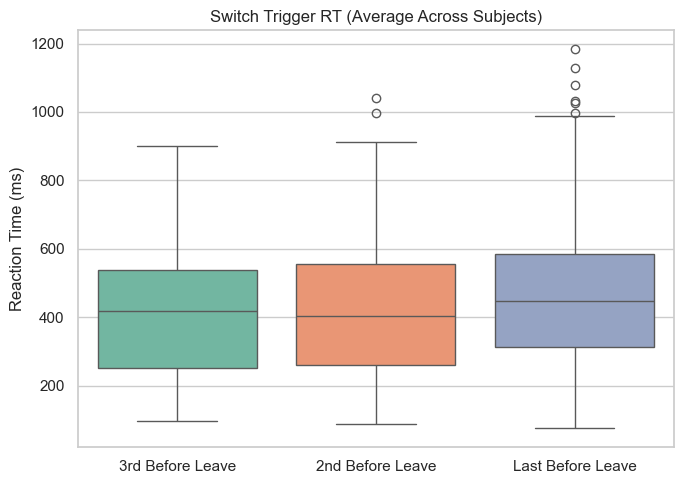

Low group size: 171


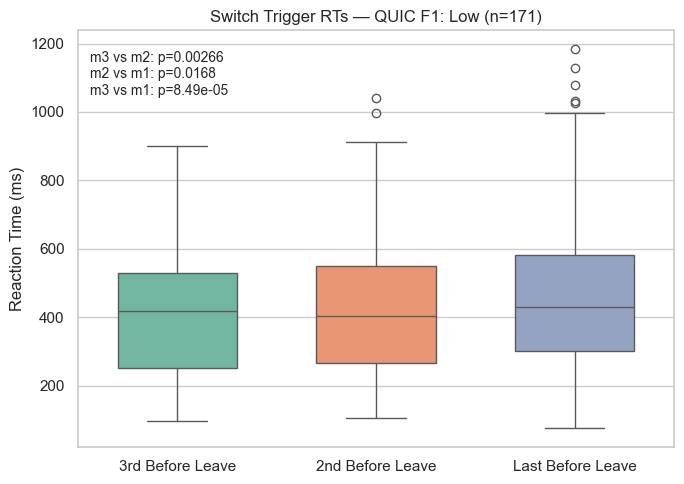

High group size: 126


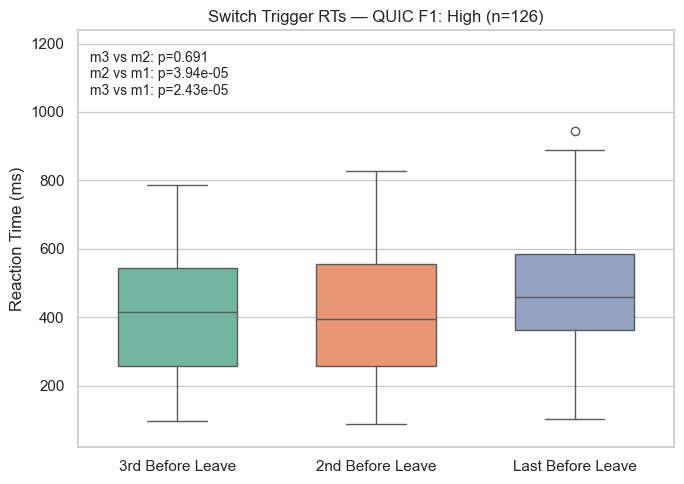

In [45]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Load massive dataframe (trial-level per planet)
# ============================================================
massive_path = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data\semi_raw_data\all_foraging_data_massive_ae_07_02_24.csv"
massive_df = pd.read_csv(massive_path)

massive_df["fileID"] = massive_df["fileID"].astype(str).str.strip()

# Parse rt_list safely
massive_df["rt_list_parsed"] = massive_df["rt_list"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else np.nan
)

# Keep only planets where prt >= 3
valid = massive_df[massive_df["prt"] >= 3].copy()


# ============================================================
# Extract last 3 RTs
# ============================================================
def last3(rt_list):
    if not isinstance(rt_list, list) or len(rt_list) < 3:
        return [np.nan, np.nan, np.nan]
    return [rt_list[-3], rt_list[-2], rt_list[-1]]

valid[["rt_m3", "rt_m2", "rt_m1"]] = valid["rt_list_parsed"].apply(
    lambda lst: pd.Series(last3(lst))
)


# ============================================================
# Compute per-subject averages
# ============================================================
subject_trigger_rt = (
    valid.groupby("fileID")[["rt_m3", "rt_m2", "rt_m1"]]
    .mean()
    .reset_index()
)

print(subject_trigger_rt.head())


# ============================================================
# Make simple boxplot
# ============================================================
plt.figure(figsize=(7,5))
sns.boxplot(
    data=subject_trigger_rt[["rt_m3", "rt_m2", "rt_m1"]],
    palette="Set2"
)
plt.xticks([0,1,2], ["3rd Before Leave", "2nd Before Leave", "Last Before Leave"])
plt.ylabel("Reaction Time (ms)")
plt.title("Switch Trigger RT (Average Across Subjects)")
plt.tight_layout()
plt.show()












import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel

# ============================================================
# Load data
# ============================================================
massive_path = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data\semi_raw_data\all_foraging_data_massive_ae_07_02_24.csv"
target_path  = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data\result_df\all_foraging_data_07_02_24.csv"

massive_df = pd.read_csv(massive_path)
df = pd.read_csv(target_path)

massive_df["fileID"] = massive_df["fileID"].astype(str).str.strip()
df["fileID"] = df["fileID"].astype(str).str.strip()

# ============================================================
# Parse rt_list
# ============================================================
massive_df["rt_list_parsed"] = massive_df["rt_list"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else np.nan
)

# Keep planets with at least 3 trials
valid = massive_df[massive_df["prt"] >= 3].copy()

def last3(lst):
    if not isinstance(lst, list) or len(lst) < 3:
        return [np.nan, np.nan, np.nan]
    return [lst[-3], lst[-2], lst[-1]]

valid[["rt_m3", "rt_m2", "rt_m1"]] = valid["rt_list_parsed"].apply(
    lambda x: pd.Series(last3(x))
)

# ============================================================
# Subject-level averages
# ============================================================
subject_trigger_rt = (
    valid.groupby("fileID")[["rt_m3", "rt_m2", "rt_m1"]]
    .mean()
    .reset_index()
)

# Merge QUIC F1
merged = subject_trigger_rt.merge(
    df[["fileID", "FA_factor_1"]],
    on="fileID", how="left"
)

# ============================================================
# Create k = 2 split (median split)
# ============================================================
median_value = merged["FA_factor_1"].median()
merged["F1_group"] = np.where(merged["FA_factor_1"] <= median_value, "Low", "High")

# ============================================================
# Compute global y-axis range
# ============================================================
y_min = merged[["rt_m3", "rt_m2", "rt_m1"]].min().min()
y_max = merged[["rt_m3", "rt_m2", "rt_m1"]].max().max()
pad = 0.05 * (y_max - y_min)
y_min -= pad
y_max += pad

# ============================================================
# Plotting function
# ============================================================
def plot_group(data, name):

    n = len(data)  # <--- group size
    print(f"{name} group size: {n}")

    plt.figure(figsize=(7,5))
    sns.boxplot(
        data=data[["rt_m3", "rt_m2", "rt_m1"]],
        palette="Set2",
        width=0.6
    )
    plt.xticks([0,1,2], ["3rd Before Leave", "2nd Before Leave", "Last Before Leave"])
    plt.ylabel("Reaction Time (ms)")
    plt.title(f"Switch Trigger RTs — QUIC F1: {name} (n={n})")
    plt.ylim(y_min, y_max)

    # ----- Paired t-tests -----
    m3 = data["rt_m3"].dropna()
    m2 = data["rt_m2"].dropna()
    m1 = data["rt_m1"].dropna()

    t_32, p_32 = ttest_rel(m3, m2, nan_policy="omit")
    t_21, p_21 = ttest_rel(m2, m1, nan_policy="omit")
    t_31, p_31 = ttest_rel(m3, m1, nan_policy="omit")

    plt.text(
        0.02, 0.95,
        f"m3 vs m2: p={p_32:.3g}\nm2 vs m1: p={p_21:.3g}\nm3 vs m1: p={p_31:.3g}",
        transform=plt.gca().transAxes,
        fontsize=10,
        verticalalignment="top"
    )

    plt.tight_layout()
    plt.show()

# ============================================================
# Generate the 2 plots (Low, High)
# ============================================================
for grp in ["Low", "High"]:
    sub = merged[merged["F1_group"] == grp].dropna(subset=["rt_m3","rt_m2","rt_m1"])
    plot_group(sub, grp)


### Parse By Planet Types

Poor (galaxy=0) planets group size: n=1500


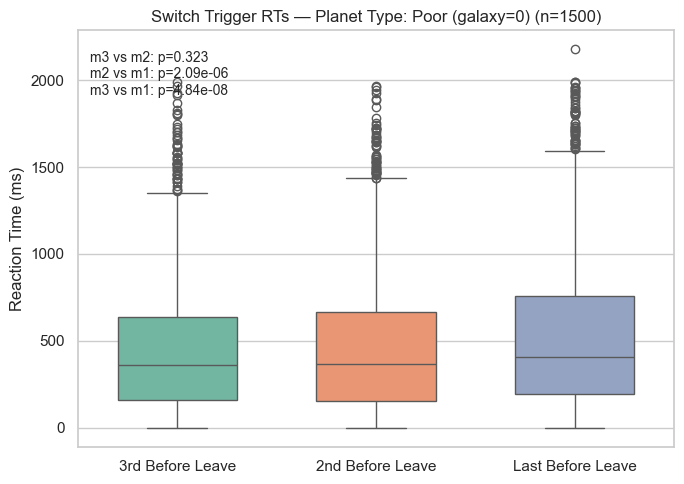

Mid (galaxy=1) planets group size: n=5351


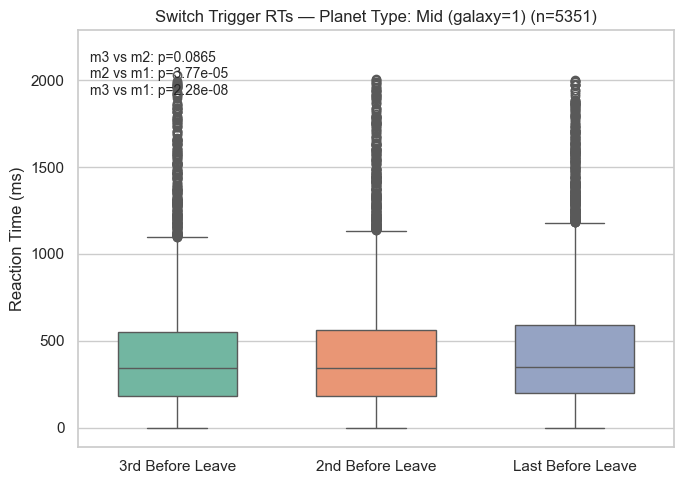

Rich (galaxy=2) planets group size: n=5116


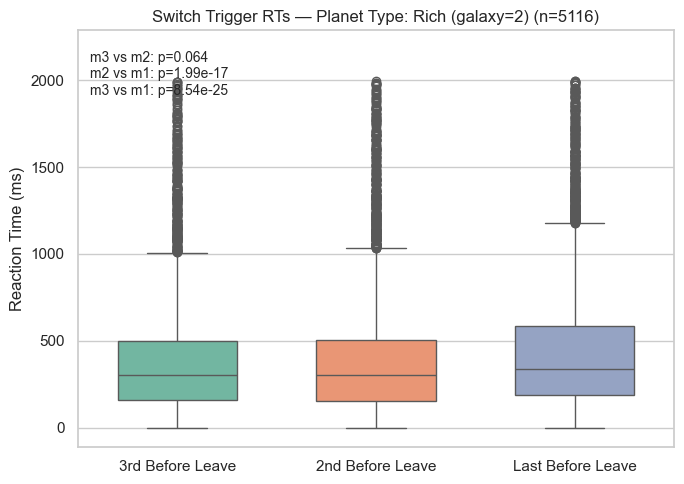

In [46]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel

# ============================================================
# Load data
# ============================================================
massive_path = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data\semi_raw_data\all_foraging_data_massive_ae_07_02_24.csv"
massive_df = pd.read_csv(massive_path)

massive_df["fileID"] = massive_df["fileID"].astype(str).str.strip()

# ============================================================
# Parse rt_list
# ============================================================
massive_df["rt_list_parsed"] = massive_df["rt_list"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else np.nan
)

# Keep only planets with at least 3 trials
valid = massive_df[massive_df["prt"] >= 3].copy()

# Extract last 3 RTs
def last3(lst):
    if not isinstance(lst, list) or len(lst) < 3:
        return [np.nan, np.nan, np.nan]
    return [lst[-3], lst[-2], lst[-1]]

valid[["rt_m3", "rt_m2", "rt_m1"]] = valid["rt_list_parsed"].apply(
    lambda x: pd.Series(last3(x))
)


# ============================================================
# Compute global y-axis range across all planets
# ============================================================
y_min = valid[["rt_m3", "rt_m2", "rt_m1"]].min().min()
y_max = valid[["rt_m3", "rt_m2", "rt_m1"]].max().max()
pad = 0.05 * (y_max - y_min)
y_min -= pad
y_max += pad


# ============================================================
# Plotting function
# ============================================================
def plot_planet_group(data, richness_label):

    n = len(data)
    print(f"{richness_label} planets group size: n={n}")

    plt.figure(figsize=(7,5))
    sns.boxplot(
        data=data[["rt_m3", "rt_m2", "rt_m1"]],
        palette="Set2",
        width=0.6
    )
    plt.xticks([0,1,2], ["3rd Before Leave", "2nd Before Leave", "Last Before Leave"])
    plt.ylabel("Reaction Time (ms)")
    plt.title(f"Switch Trigger RTs — Planet Type: {richness_label} (n={n})")
    plt.ylim(y_min, y_max)

    # ----- Paired T-tests -----
    m3 = data["rt_m3"].dropna()
    m2 = data["rt_m2"].dropna()
    m1 = data["rt_m1"].dropna()

    t_32, p_32 = ttest_rel(m3, m2, nan_policy="omit")
    t_21, p_21 = ttest_rel(m2, m1, nan_policy="omit")
    t_31, p_31 = ttest_rel(m3, m1, nan_policy="omit")

    plt.text(
        0.02, 0.95,
        f"m3 vs m2: p={p_32:.3g}\n"
        f"m2 vs m1: p={p_21:.3g}\n"
        f"m3 vs m1: p={p_31:.3g}",
        transform=plt.gca().transAxes,
        fontsize=10,
        verticalalignment="top"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# Split by planet richness
# ============================================================
groups = {
    "Poor (galaxy=0)": valid[valid["galaxy"] == 0],
    "Mid (galaxy=1)":  valid[valid["galaxy"] == 1],
    "Rich (galaxy=2)": valid[valid["galaxy"] == 2],
}

# ============================================================
# Produce all three plots
# ============================================================
for label, data in groups.items():
    sub = data.dropna(subset=["rt_m3","rt_m2","rt_m1"])
    plot_planet_group(sub, label)
